Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0250
##########################################################################################

******************************************************************************************
STARTING LINEAR MASS = 580.0000 FOR DAMPING = 0.0250
******************************************************************************************

RUNNING BRIDGE FREQUENCY = 1.200 Hz

--------------------------

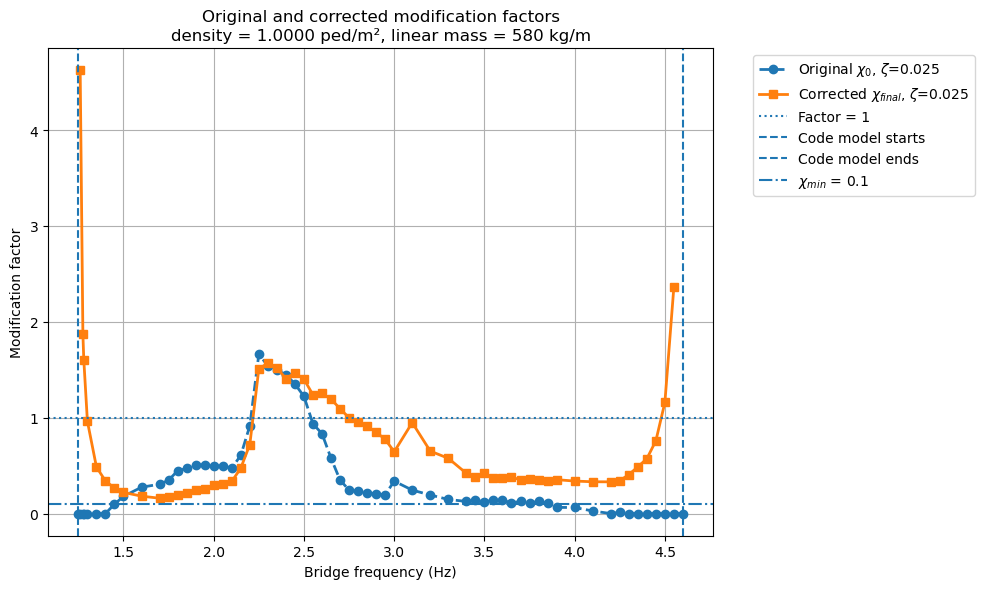

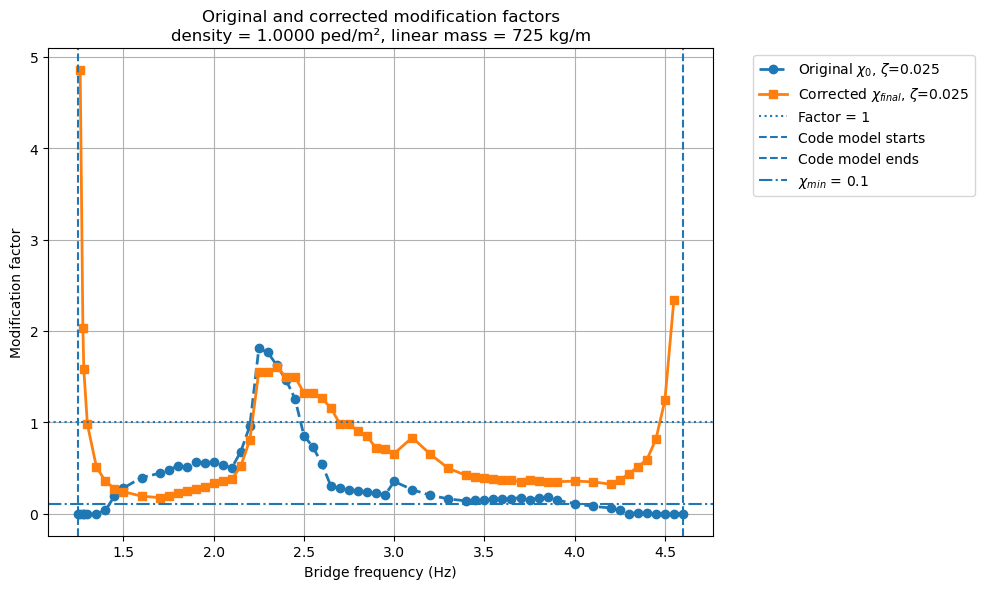

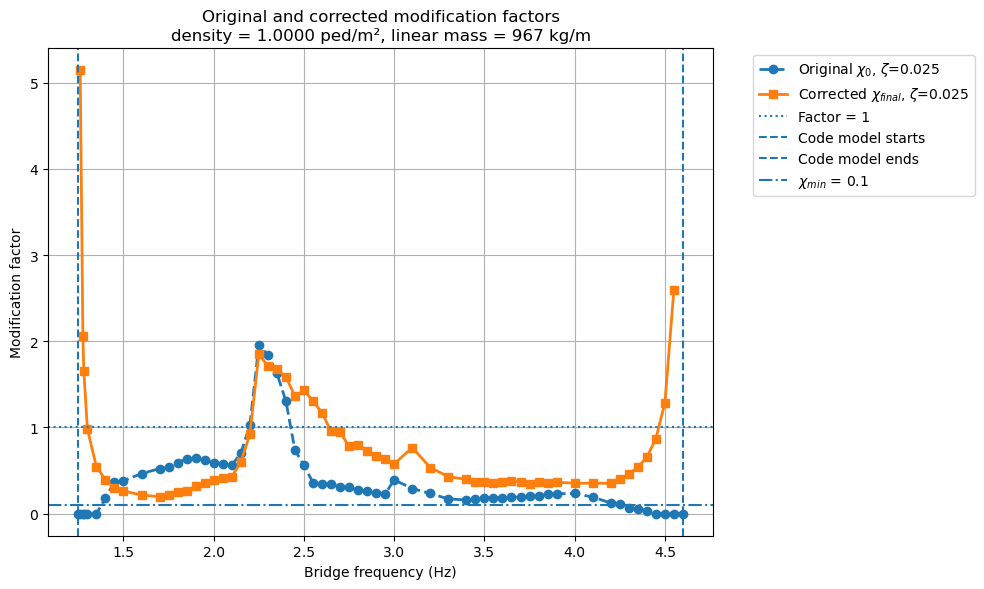

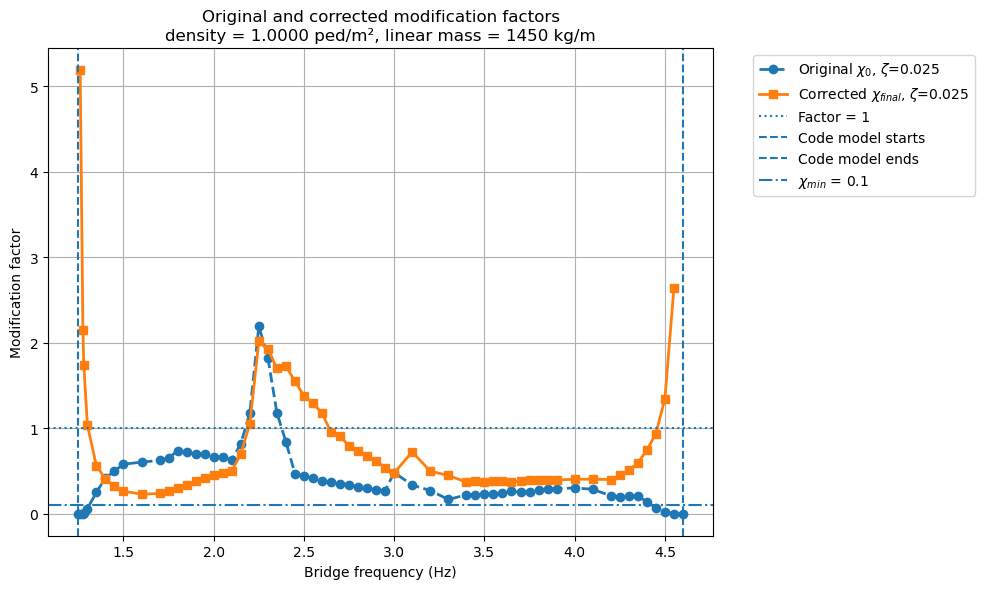

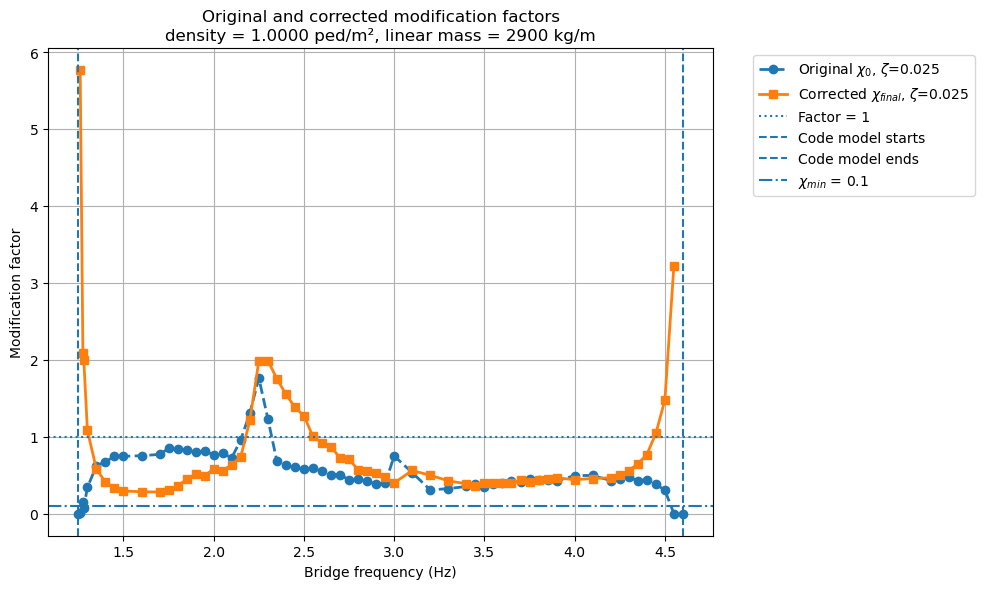


Correction method map
---------------------
     bridge_frequency  initial_modification_factor  final_modification_factor  \
0               1.200                          NaN                        NaN   
3               1.250                          0.0                        NaN   
6               1.260                          0.0                   4.626276   
9               1.275                          0.0                   1.869872   
12              1.280                          0.0                   1.604485   
..                ...                          ...                        ...   
174             4.400                          0.0                   0.571880   
177             4.450                          0.0                   0.759019   
180             4.500                          0.0                   1.159025   
183             4.550                          0.0                   2.368172   
186             4.600                          0.0              

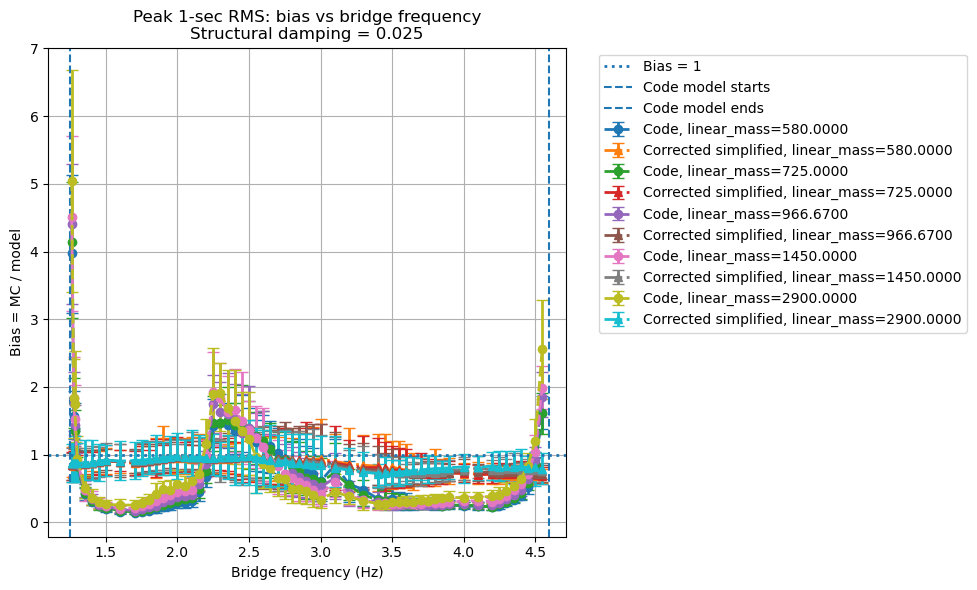

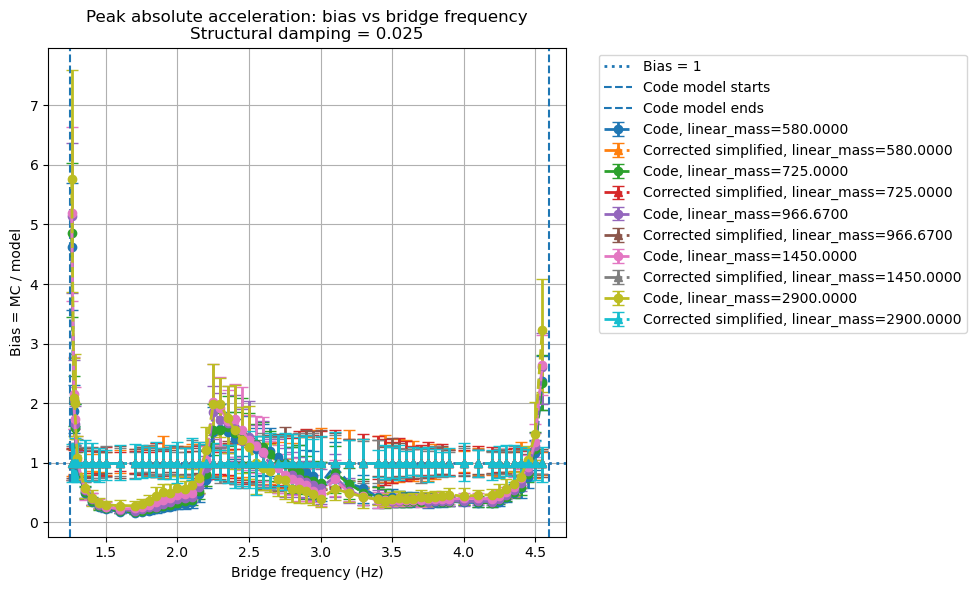

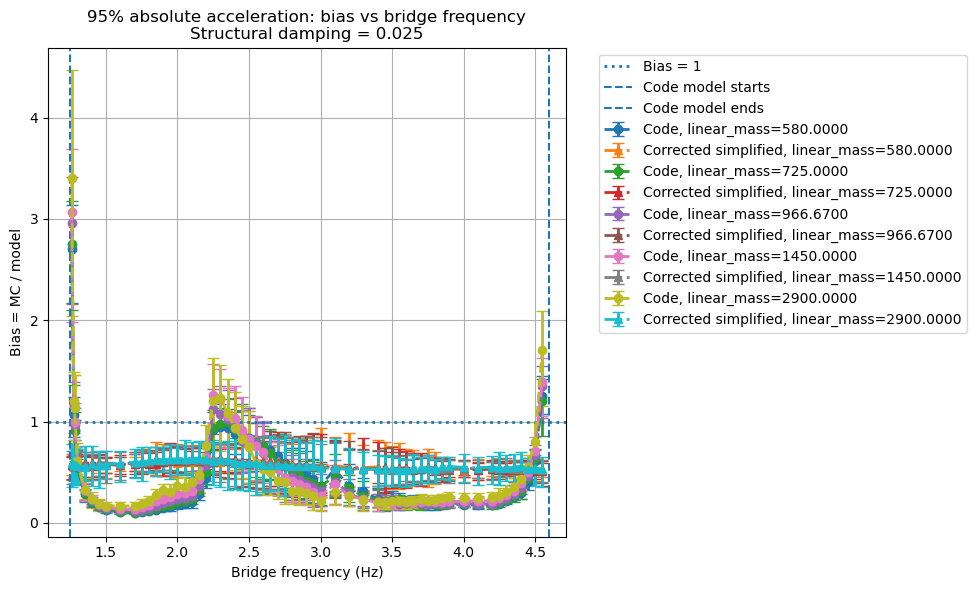

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias_model2 import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0
target_beamdamp_values = [0.025]
# Give one damping ratio, or more if needed.
# Example: run all densities for structural damping = 0.020
linear_mass_values = [580.00, 725.00, 966.67, 1450.00, 2900.00]

bridge_frequencies_to_run = [
    1.20, 1.25, 1.26, 1.275, 1.28, 1.30, 1.35, 1.40, 1.45, 1.5,  1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.40, 3.45, 3.5, 3.55, 3.60, 3.65, 3.70, 3.75, 3.80, 3.85, 3.90, 4.00, 4.10, 4.20, 4.25, 4.30, 4.35, 4.40, 4.45, 4.50, 4.55, 4.60


]

# Put all densities you want for the selected damping ratio here.
density = 1.0000

eps = 1e-12


# --------------------------------------------------
# Code-model validity and chi-threshold settings
# --------------------------------------------------
# The code UDL model is treated as valid only inside this frequency range.
# Outside this range, MC/reference results are stored and deterministic
# predictions are set to NaN.
CODE_MODEL_MIN_FREQ = 1.25
CODE_MODEL_MAX_FREQ = 4.60

# If the theoretical modification factor chi_0 is below this value,
# chi_0 is treated as unreliable and direct code-bias correction is used.
CHI_MIN_FOR_THEORY = 0.1


# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"


# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: save name for each density-damping case
# --------------------------------------------------
def make_summary_filename(density, target_beamdamp, linear_mass):
    return (
        f"density{density:.4f}"
        f"_damping{target_beamdamp:.3f}"
        f"_lm{linear_mass:.0f}"
        f"_bias_summary.pkl"
    )
# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Helper: choose mean / median / p95 statistic
# --------------------------------------------------
def choose_stat(values, stat_name):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    if stat_name == "mean":
        return np.mean(values)

    elif stat_name == "median":
        return np.percentile(values, 50)

    elif stat_name == "p95":
        return np.percentile(values, 95)

    else:
        raise ValueError("CORRECTION_STAT must be 'mean', 'median', or 'p95'.")


# --------------------------------------------------
# Helper: safe bias distribution
# --------------------------------------------------
def safe_bias_distribution(Y_ref, model_value, eps=1e-12):
    Y_ref = np.asarray(Y_ref, dtype=float)
    Y_ref = Y_ref[np.isfinite(Y_ref)]

    if not np.isfinite(model_value):
        return np.full_like(Y_ref, np.nan, dtype=float)

    if abs(model_value) < eps:
        return np.full_like(Y_ref, np.nan, dtype=float)

    return Y_ref / model_value


# --------------------------------------------------
# Helper: safely summarize bias distribution
# --------------------------------------------------
def summarize_bias(B):
    B = np.asarray(B, dtype=float)
    B = B[np.isfinite(B)]

    if len(B) == 0:
        return np.nan, np.nan, np.nan, np.nan

    return (
        np.mean(B),
        np.percentile(B, 5),
        np.percentile(B, 50),
        np.percentile(B, 95),
    )


# --------------------------------------------------
# Helper: empty measures dictionary
# --------------------------------------------------
def empty_measures(measure_specs):
    return {
        spec["code_key"]: np.nan
        for spec in measure_specs.values()
    }


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    # This is only kept for plotting all densities together at the end.
    # Each density is saved separately immediately after that density is finished.
    all_summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            # --------------------------------------------------
            # IMPORTANT CHANGE:
            # density loop is outside the frequency loop.
            # Therefore, once all frequencies for one density are finished,
            # that density gets saved immediately to its own PKL file.
            # --------------------------------------------------
            for linear_mass in linear_mass_values:

                density_summary_rows = []

                print("\n" + "*" * 90)
                print(f"STARTING LINEAR MASS = {linear_mass:.4f} FOR DAMPING = {target_beamdamp:.4f}")
                print("*" * 90)

                for target_bf in bridge_frequencies_to_run:

                    print("\n" + "=" * 80)
                    print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                    print("=" * 80)

                    BeamFreq = np.array([target_bf, 4.0 * target_bf])
                    Beamdamp = np.array([target_beamdamp])

                    print("\n" + "-" * 70)
                    print(f"Running linear mass = {linear_mass:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width,
                            linear_mass
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]
                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CASE 1: OUTSIDE CODE MODEL RANGE
                    # ==================================================
                    code_model_exists = (
                        CODE_MODEL_MIN_FREQ <= target_bf <= CODE_MODEL_MAX_FREQ
                    )

                    if not code_model_exists:

                        print("\nCode UDL model is not defined for this frequency.")
                        print(
                            f"target_bf = {target_bf:.3f} Hz is outside "
                            f"[{CODE_MODEL_MIN_FREQ:.3f}, {CODE_MODEL_MAX_FREQ:.3f}] Hz"
                        )
                        print("Only MC/reference response will be stored.")

                        for measure_name, spec in measure_specs.items():

                            Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                            Y_ref = Y_ref[np.isfinite(Y_ref)]

                            row = {
                                "bridge_frequency": target_bf,
                                "target_beamdamp": target_beamdamp,
                                "target_density": density,
                                "actual_density": actual_density,
                                "linear_mass": linear_mass,
                                "total_peds": total_peds_int,
                                "Tocity": Tocity,
                                "Outcity": Outcity,

                                "mean_modal_mass_ratio": overall_mean_mass_ratio,
                                "mass_ratio_used_for_interpolation": np.nan,

                                "initial_modification_factor": np.nan,
                                "residual_correction_factor": np.nan,
                                "final_modification_factor": np.nan,

                                "calibration_measure": CALIBRATION_MEASURE,
                                "correction_stat": CORRECTION_STAT,
                                "correction_method": "outside_code_model_range",
                                "interpolation_status": "not_attempted",
                                "chi_min_for_theory": CHI_MIN_FOR_THEORY,

                                "measure": measure_name,

                                "mc_mean": np.mean(Y_ref),
                                "mc_p5": np.percentile(Y_ref, 5),
                                "mc_p50": np.percentile(Y_ref, 50),
                                "mc_p95": np.percentile(Y_ref, 95),

                                "code_prediction": np.nan,
                                "simplified_prediction": np.nan,
                                "corrected_prediction": np.nan,

                                "code_bias_mean": np.nan,
                                "code_bias_p5": np.nan,
                                "code_bias_p50": np.nan,
                                "code_bias_p95": np.nan,

                                "simplified_bias_mean": np.nan,
                                "simplified_bias_p5": np.nan,
                                "simplified_bias_p50": np.nan,
                                "simplified_bias_p95": np.nan,

                                "corrected_bias_mean": np.nan,
                                "corrected_bias_p5": np.nan,
                                "corrected_bias_p50": np.nan,
                                "corrected_bias_p95": np.nan,
                            }

                            density_summary_rows.append(row)
                            all_summary_rows.append(row)

                        continue

                    # ==================================================
                    # CASE 2: CODE MODEL EXISTS
                    # ==================================================

                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor = np.nan
                    interp_details = None
                    interpolation_status = "not_attempted"

                    try:
                        x_factor, interp_details = interpolate_modification_factor_banded(
                            results_all=ff_results_all,
                            target_bf=target_bf,
                            target_beamdamp=target_beamdamp,
                            target_mass_ratio=target_mass_ratio_used,
                            damping_values=ff_damping_values,
                            densities=ff_densities,
                            bands_to_combine=ff_bands_to_combine,
                            factor_key="modification_factor"
                        )

                        x_factor = float(x_factor)
                        interpolation_status = "success"

                    except Exception as e:
                        print("\nModification-factor interpolation failed.")
                        print(f"Reason: {e}")
                        x_factor = np.nan
                        interpolation_status = "failed"

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor}")
                    print(f"Interpolation status              = {interpolation_status}")

                    # --------------------------------------------------
                    # Original simplified deterministic model using chi_0
                    # This is stored for comparison only.
                    # --------------------------------------------------
                    if np.isfinite(x_factor):

                        simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                            Tocity=Tocity,
                            Outcity=Outcity,
                            Length=Length,
                            Width=Width,
                            BeamFreq=BeamFreq,
                            Beamdamp=Beamdamp,
                            linear_mass=linear_mass,
                            hht=hht,
                            t_end=t_end,
                            mean_mass_ratio=overall_mean_mass_ratio,
                            mass_ratio_limit=0.05,
                            steady_start_time=steady_start_time,
                            numbers=1,
                            modify_both_modes=False,
                            force_reduction_factor=x_factor
                        )

                    else:
                        simplified_result = None
                        simplified_measures = empty_measures(measure_specs)

                    # --------------------------------------------------
                    # Decide correction method
                    # --------------------------------------------------
                    # Direct correction is triggered by the reliability of chi_0,
                    # not by a manually assigned frequency region.
                    #
                    # If chi_0 is missing or too small, the usual residual factor
                    # lambda = Y_MC / Y_simplified becomes unstable because
                    # Y_simplified = chi_0 * Y_code is near zero.
                    # In that case, directly calibrate the final factor from
                    # the code-model bias: chi_final = xi = stat(Y_MC / Y_code).
                    use_direct_code_bias_correction = False

                    if not np.isfinite(x_factor):
                        use_direct_code_bias_correction = True

                    elif abs(x_factor) < CHI_MIN_FOR_THEORY:
                        use_direct_code_bias_correction = True

                    # Calibration reference distribution
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    code_val_cal = code_measures[cal_spec["code_key"]]

                    # --------------------------------------------------
                    # Direct code-bias correction
                    # --------------------------------------------------
                    if use_direct_code_bias_correction:

                        print("\nUsing DIRECT CODE-BIAS correction.")
                        print("Reason: missing chi_0 or chi_0 below the reliability threshold.")

                        correction_method = "direct_code_bias"

                        if (not np.isfinite(code_val_cal)) or (abs(code_val_cal) < eps):

                            print("WARNING: code prediction is zero or near zero.")
                            print("No multiplicative correction can recover the reference response.")

                            final_modification_factor = np.nan
                            residual_correction_factor = np.nan
                            correction_method = "failed_code_prediction_zero"

                        else:

                            B_code_cal = Y_cal / code_val_cal

                            final_modification_factor = choose_stat(
                                B_code_cal,
                                CORRECTION_STAT
                            )

                            residual_correction_factor = np.nan

                            print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                            print(f"Correction statistic       = {CORRECTION_STAT}")
                            print(f"Code calibration value     = {code_val_cal:.6e}")
                            print(f"Final factor from code bias = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Normal chi_0 * residual correction
                    # --------------------------------------------------
                    else:

                        print("\nUsing NORMAL theoretical + residual correction.")

                        correction_method = "theory_times_residual"

                        simp_val_cal = simplified_measures[cal_spec["code_key"]]

                        if (not np.isfinite(simp_val_cal)) or (abs(simp_val_cal) < eps):

                            print("WARNING: simplified prediction is zero or near zero.")
                            print("Switching to direct code-bias correction instead.")

                            if (not np.isfinite(code_val_cal)) or (abs(code_val_cal) < eps):

                                final_modification_factor = np.nan
                                residual_correction_factor = np.nan
                                correction_method = "failed_code_prediction_zero"

                            else:

                                B_code_cal = Y_cal / code_val_cal

                                final_modification_factor = choose_stat(
                                    B_code_cal,
                                    CORRECTION_STAT
                                )

                                residual_correction_factor = np.nan
                                correction_method = "direct_code_bias_fallback"

                        else:

                            B_simp_cal = Y_cal / simp_val_cal

                            residual_correction_factor = choose_stat(
                                B_simp_cal,
                                CORRECTION_STAT
                            )

                            final_modification_factor = x_factor * residual_correction_factor

                            print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                            print(f"Correction statistic       = {CORRECTION_STAT}")
                            print(f"Initial factor chi_0        = {x_factor:.6f}")
                            print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                            print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    if np.isfinite(final_modification_factor):

                        corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                            Tocity=Tocity,
                            Outcity=Outcity,
                            Length=Length,
                            Width=Width,
                            BeamFreq=BeamFreq,
                            Beamdamp=Beamdamp,
                            linear_mass=linear_mass,
                            hht=hht,
                            t_end=t_end,
                            mean_mass_ratio=overall_mean_mass_ratio,
                            mass_ratio_limit=0.05,
                            steady_start_time=steady_start_time,
                            numbers=1,
                            modify_both_modes=False,
                            force_reduction_factor=final_modification_factor
                        )

                    else:

                        corrected_result = None
                        corrected_measures = empty_measures(measure_specs)

                    print("\nCorrection summary")
                    print("------------------")
                    print(f"Correction method             = {correction_method}")
                    print(f"Initial factor chi_0           = {x_factor}")
                    print(f"Residual correction factor     = {residual_correction_factor}")
                    print(f"Final modification factor      = {final_modification_factor}")

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = safe_bias_distribution(Y_ref, code_val, eps=eps)
                        B_simp = safe_bias_distribution(Y_ref, simp_val, eps=eps)
                        B_corr = safe_bias_distribution(Y_ref, corr_val, eps=eps)

                        (
                            code_bias_mean,
                            code_bias_p5,
                            code_bias_p50,
                            code_bias_p95,
                        ) = summarize_bias(B_code)

                        (
                            simplified_bias_mean,
                            simplified_bias_p5,
                            simplified_bias_p50,
                            simplified_bias_p95,
                        ) = summarize_bias(B_simp)

                        (
                            corrected_bias_mean,
                            corrected_bias_p5,
                            corrected_bias_p50,
                            corrected_bias_p95,
                        ) = summarize_bias(B_corr)

                        row = {
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "linear_mass": linear_mass,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,
                            "correction_method": correction_method,
                            "interpolation_status": interpolation_status,
                            "chi_min_for_theory": CHI_MIN_FOR_THEORY,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": code_bias_mean,
                            "code_bias_p5": code_bias_p5,
                            "code_bias_p50": code_bias_p50,
                            "code_bias_p95": code_bias_p95,

                            "simplified_bias_mean": simplified_bias_mean,
                            "simplified_bias_p5": simplified_bias_p5,
                            "simplified_bias_p50": simplified_bias_p50,
                            "simplified_bias_p95": simplified_bias_p95,

                            "corrected_bias_mean": corrected_bias_mean,
                            "corrected_bias_p5": corrected_bias_p5,
                            "corrected_bias_p50": corrected_bias_p50,
                            "corrected_bias_p95": corrected_bias_p95,
                        }

                        density_summary_rows.append(row)
                        all_summary_rows.append(row)

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val}")
                        print(f"  Simplified prediction     = {simp_val}")
                        print(f"  Corrected prediction      = {corr_val}")
                        print(f"  Code mean bias            = {code_bias_mean}")
                        print(f"  Simplified mean bias      = {simplified_bias_mean}")
                        print(f"  Corrected simplified bias = {corrected_bias_mean}")

                # ==================================================
                # SAVE THIS DENSITY IMMEDIATELY
                # ==================================================
                density_summary_df = pd.DataFrame(density_summary_rows)
                summary_pkl = make_summary_filename(density, target_beamdamp, linear_mass)
                with open(summary_pkl, "wb") as f:
                    pickle.dump(density_summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

                print("\n" + "=" * 80)
                print("Saved density summary file:")
                print(summary_pkl)
                print("Rows saved:", len(density_summary_df))
                print("=" * 80)

    # ==================================================
    # PLOTS USING ALL RESULTS FROM THIS RUN
    # No combined PKL is saved here; only individual density PKLs are saved above.
    # ==================================================
    summary_df = pd.DataFrame(all_summary_rows)

    if len(summary_df) == 0:
        print("No results to plot.")
    else:
        # ==================================================
        # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
        # One plot per density, all damping ratios included
        # ==================================================
        factor_df = summary_df.drop_duplicates(
            subset=[
                "bridge_frequency",
                "target_density",
                "target_beamdamp",
                "linear_mass"
            ]
        ).copy()

        for linear_mass in linear_mass_values:

            plt.figure(figsize=(10, 6))

            for target_beamdamp in target_beamdamp_values:

                sub = factor_df[
                    (np.isclose(factor_df["target_density"], density)) &
                    (np.isclose(factor_df["target_beamdamp"], target_beamdamp)) &
                    (np.isclose(factor_df["linear_mass"], linear_mass))
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                plt.plot(
                    sub["bridge_frequency"],
                    sub["initial_modification_factor"],
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
                )

                plt.plot(
                    sub["bridge_frequency"],
                    sub["final_modification_factor"],
                    marker="s",
                    linestyle="-",
                    linewidth=2,
                    label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=1.5,
                label="Factor = 1"
            )

            plt.axvline(
                CODE_MODEL_MIN_FREQ,
                linestyle="--",
                linewidth=1.5,
                label="Code model starts"
            )

            plt.axvline(
                CODE_MODEL_MAX_FREQ,
                linestyle="--",
                linewidth=1.5,
                label="Code model ends"
            )

            plt.axhline(
                CHI_MIN_FOR_THEORY,
                linestyle="-.",
                linewidth=1.5,
                label=rf"$\chi_{{min}}$ = {CHI_MIN_FOR_THEORY}"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Modification factor")
            plt.title(
                f"Original and corrected modification factors\n"
                f"density = {density:.4f} ped/m², "
                f"linear mass = {linear_mass:.0f} kg/m"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

        # ==================================================
        # PLOT 2: CORRECTION METHOD MAP
        # ==================================================
        for linear_mass in linear_mass_values:
            
            for target_beamdamp in target_beamdamp_values:

                sub = factor_df[
                    (np.isclose(factor_df["target_density"], density)) &
                    (np.isclose(factor_df["target_beamdamp"], target_beamdamp)) &
                    (np.isclose(factor_df["linear_mass"], linear_mass))
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                print("\nCorrection method map")
                print("---------------------")
                print(
                    sub[
                        [
                            "bridge_frequency",
                            "initial_modification_factor",
                            "final_modification_factor",
                            "correction_method",
                            "interpolation_status",
                            "linear_mass"
                        ]
                    ]
                )

        # ==================================================
        # PLOTS 3-5: ERROR BARS FOR EACH RESPONSE MEASURE
        # One plot per vibration measure and damping ratio
        # Code and corrected simplified are plotted.
        # Points outside [1.25, 4.60] Hz appear as NaN for deterministic models.
        # ==================================================
        for target_beamdamp in target_beamdamp_values:

            for measure_name in measure_specs.keys():

                plt.figure(figsize=(10, 6))

                for linear_mass in linear_mass_values:

                    sub = summary_df[
                        (np.isclose(summary_df["target_beamdamp"], target_beamdamp)) &
                        (np.isclose(summary_df["linear_mass"], linear_mass)) &
                        (summary_df["measure"].astype(str) == str(measure_name))
                    ].copy()

                    sub = sub.sort_values("bridge_frequency")

                    x = sub["bridge_frequency"].values

                    # -----------------------------
                    # Original code bias
                    # -----------------------------
                    y_code = sub["code_bias_mean"].values
                    y_code_p5 = sub["code_bias_p5"].values
                    y_code_p95 = sub["code_bias_p95"].values

                    yerr_code = np.vstack([
                        y_code - y_code_p5,
                        y_code_p95 - y_code
                    ])

                    plt.errorbar(
                        x,
                        y_code,
                        yerr=yerr_code,
                        marker="o",
                        linestyle="--",
                        linewidth=2,
                        capsize=4,
                        label=f"Code, linear_mass={linear_mass:.4f}"
                    )

                    # -----------------------------
                    # Corrected simplified model bias
                    # -----------------------------
                    y_corr = sub["corrected_bias_mean"].values
                    y_corr_p5 = sub["corrected_bias_p5"].values
                    y_corr_p95 = sub["corrected_bias_p95"].values

                    yerr_corr = np.vstack([
                        y_corr - y_corr_p5,
                        y_corr_p95 - y_corr
                    ])

                    plt.errorbar(
                        x,
                        y_corr,
                        yerr=yerr_corr,
                        marker="^",
                        linestyle="-.",
                        linewidth=2,
                        capsize=4,
                        label=f"Corrected simplified, linear_mass={linear_mass:.4f}"
                    )

                plt.axhline(
                    1.0,
                    linestyle=":",
                    linewidth=2,
                    label="Bias = 1"
                )

                plt.axvline(
                    CODE_MODEL_MIN_FREQ,
                    linestyle="--",
                    linewidth=1.5,
                    label="Code model starts"
                )

                plt.axvline(
                    CODE_MODEL_MAX_FREQ,
                    linestyle="--",
                    linewidth=1.5,
                    label="Code model ends"
                )

                plt.xlabel("Bridge frequency (Hz)")
                plt.ylabel("Bias = MC / model")
                plt.title(
                    f"{measure_name}: bias vs bridge frequency\n"
                    f"Structural damping = {target_beamdamp:.3f}"
                )

                plt.grid(True)
                plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
                plt.tight_layout()
                plt.show()


Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0050
##########################################################################################

******************************************************************************************
STARTING LINEAR MASS = 580.0000 FOR DAMPING = 0.0050
******************************************************************************************

RUNNING BRIDGE FREQUENCY = 1.200 Hz

--------------------------

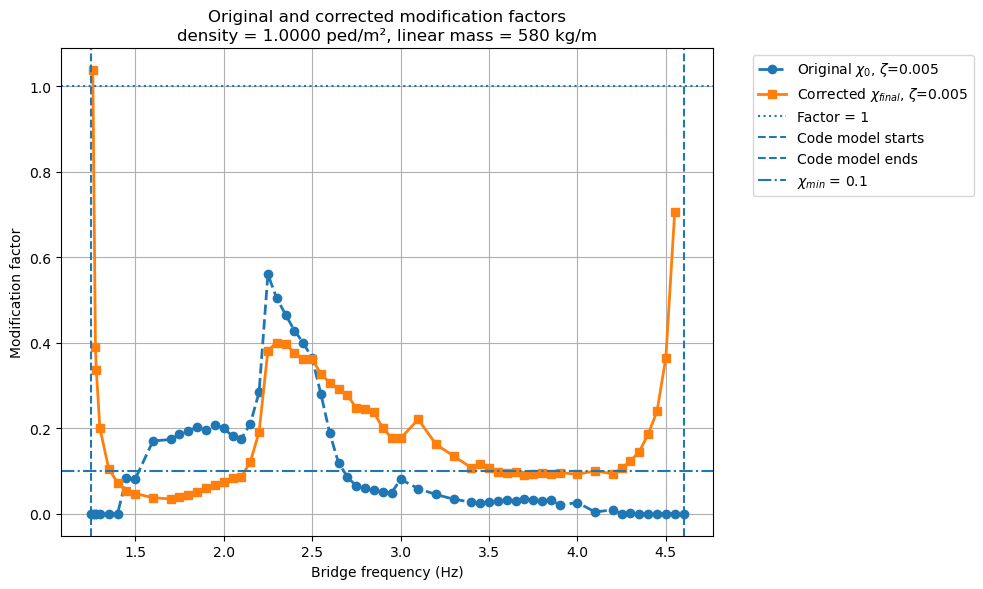


Correction method map
---------------------
     bridge_frequency  initial_modification_factor  final_modification_factor  \
0               1.200                          NaN                        NaN   
3               1.250                          0.0                        NaN   
6               1.260                          0.0                   1.037703   
9               1.275                          0.0                   0.388870   
12              1.280                          0.0                   0.335197   
..                ...                          ...                        ...   
174             4.400                          0.0                   0.185858   
177             4.450                          0.0                   0.238822   
180             4.500                          0.0                   0.364865   
183             4.550                          0.0                   0.704997   
186             4.600                          0.0              

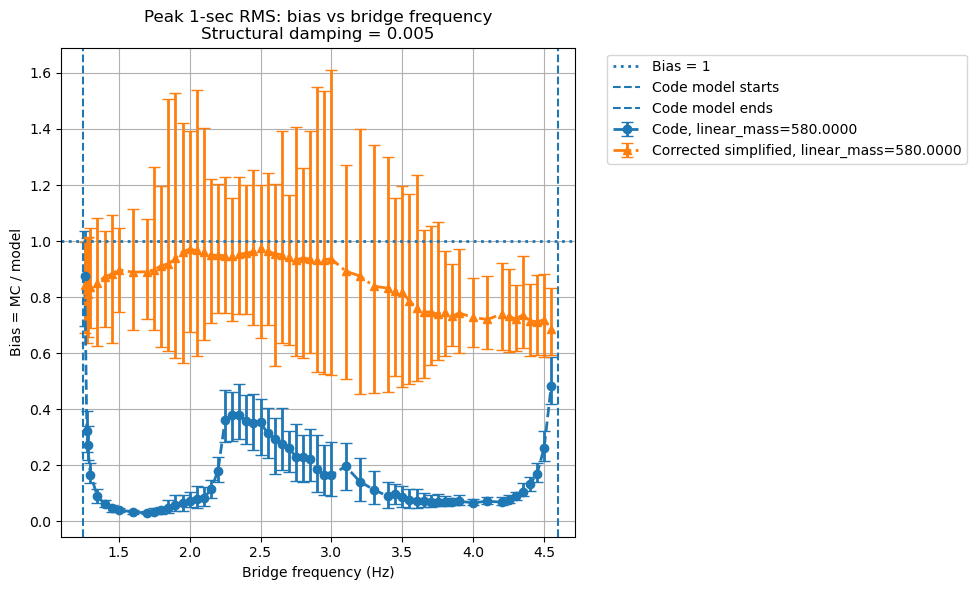

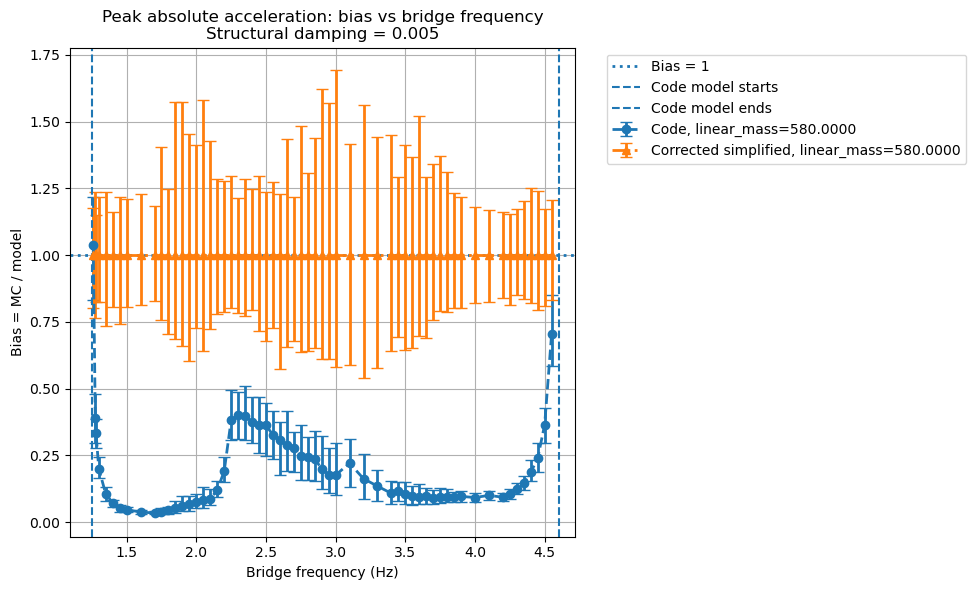

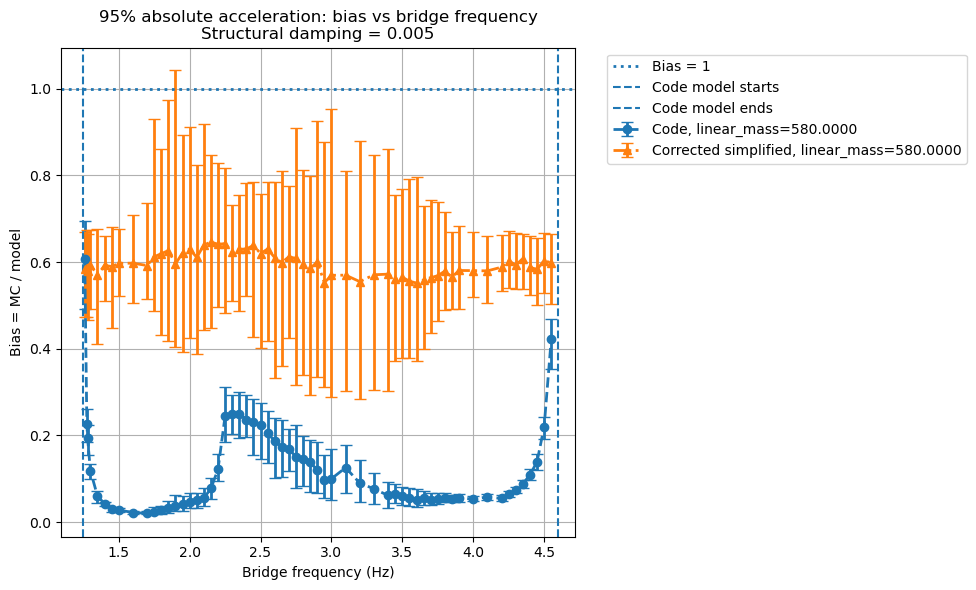

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias_model2 import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0
target_beamdamp_values = [0.005]
# Give one damping ratio, or more if needed.
# Example: run all densities for structural damping = 0.020
linear_mass_values = [580.00]

bridge_frequencies_to_run = [
    1.20, 1.25, 1.26, 1.275, 1.28, 1.30, 1.35, 1.40, 1.45, 1.5,  1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.40, 3.45, 3.5, 3.55, 3.60, 3.65, 3.70, 3.75, 3.80, 3.85, 3.90, 4.00, 4.10, 4.20, 4.25, 4.30, 4.35, 4.40, 4.45, 4.50, 4.55, 4.60


]

# Put all densities you want for the selected damping ratio here.
density = 1.0000

eps = 1e-12


# --------------------------------------------------
# Code-model validity and chi-threshold settings
# --------------------------------------------------
# The code UDL model is treated as valid only inside this frequency range.
# Outside this range, MC/reference results are stored and deterministic
# predictions are set to NaN.
CODE_MODEL_MIN_FREQ = 1.25
CODE_MODEL_MAX_FREQ = 4.60

# If the theoretical modification factor chi_0 is below this value,
# chi_0 is treated as unreliable and direct code-bias correction is used.
CHI_MIN_FOR_THEORY = 0.1


# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"


# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: save name for each density-damping case
# --------------------------------------------------
def make_summary_filename(density, target_beamdamp, linear_mass):
    return (
        f"density{density:.4f}"
        f"_damping{target_beamdamp:.3f}"
        f"_lm{linear_mass:.0f}"
        f"_bias_summary.pkl"
    )
# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Helper: choose mean / median / p95 statistic
# --------------------------------------------------
def choose_stat(values, stat_name):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    if stat_name == "mean":
        return np.mean(values)

    elif stat_name == "median":
        return np.percentile(values, 50)

    elif stat_name == "p95":
        return np.percentile(values, 95)

    else:
        raise ValueError("CORRECTION_STAT must be 'mean', 'median', or 'p95'.")


# --------------------------------------------------
# Helper: safe bias distribution
# --------------------------------------------------
def safe_bias_distribution(Y_ref, model_value, eps=1e-12):
    Y_ref = np.asarray(Y_ref, dtype=float)
    Y_ref = Y_ref[np.isfinite(Y_ref)]

    if not np.isfinite(model_value):
        return np.full_like(Y_ref, np.nan, dtype=float)

    if abs(model_value) < eps:
        return np.full_like(Y_ref, np.nan, dtype=float)

    return Y_ref / model_value


# --------------------------------------------------
# Helper: safely summarize bias distribution
# --------------------------------------------------
def summarize_bias(B):
    B = np.asarray(B, dtype=float)
    B = B[np.isfinite(B)]

    if len(B) == 0:
        return np.nan, np.nan, np.nan, np.nan

    return (
        np.mean(B),
        np.percentile(B, 5),
        np.percentile(B, 50),
        np.percentile(B, 95),
    )


# --------------------------------------------------
# Helper: empty measures dictionary
# --------------------------------------------------
def empty_measures(measure_specs):
    return {
        spec["code_key"]: np.nan
        for spec in measure_specs.values()
    }


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    # This is only kept for plotting all densities together at the end.
    # Each density is saved separately immediately after that density is finished.
    all_summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            # --------------------------------------------------
            # IMPORTANT CHANGE:
            # density loop is outside the frequency loop.
            # Therefore, once all frequencies for one density are finished,
            # that density gets saved immediately to its own PKL file.
            # --------------------------------------------------
            for linear_mass in linear_mass_values:

                density_summary_rows = []

                print("\n" + "*" * 90)
                print(f"STARTING LINEAR MASS = {linear_mass:.4f} FOR DAMPING = {target_beamdamp:.4f}")
                print("*" * 90)

                for target_bf in bridge_frequencies_to_run:

                    print("\n" + "=" * 80)
                    print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                    print("=" * 80)

                    BeamFreq = np.array([target_bf, 4.0 * target_bf])
                    Beamdamp = np.array([target_beamdamp])

                    print("\n" + "-" * 70)
                    print(f"Running linear mass = {linear_mass:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width,
                            linear_mass
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]
                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CASE 1: OUTSIDE CODE MODEL RANGE
                    # ==================================================
                    code_model_exists = (
                        CODE_MODEL_MIN_FREQ <= target_bf <= CODE_MODEL_MAX_FREQ
                    )

                    if not code_model_exists:

                        print("\nCode UDL model is not defined for this frequency.")
                        print(
                            f"target_bf = {target_bf:.3f} Hz is outside "
                            f"[{CODE_MODEL_MIN_FREQ:.3f}, {CODE_MODEL_MAX_FREQ:.3f}] Hz"
                        )
                        print("Only MC/reference response will be stored.")

                        for measure_name, spec in measure_specs.items():

                            Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                            Y_ref = Y_ref[np.isfinite(Y_ref)]

                            row = {
                                "bridge_frequency": target_bf,
                                "target_beamdamp": target_beamdamp,
                                "target_density": density,
                                "actual_density": actual_density,
                                "linear_mass": linear_mass,
                                "total_peds": total_peds_int,
                                "Tocity": Tocity,
                                "Outcity": Outcity,

                                "mean_modal_mass_ratio": overall_mean_mass_ratio,
                                "mass_ratio_used_for_interpolation": np.nan,

                                "initial_modification_factor": np.nan,
                                "residual_correction_factor": np.nan,
                                "final_modification_factor": np.nan,

                                "calibration_measure": CALIBRATION_MEASURE,
                                "correction_stat": CORRECTION_STAT,
                                "correction_method": "outside_code_model_range",
                                "interpolation_status": "not_attempted",
                                "chi_min_for_theory": CHI_MIN_FOR_THEORY,

                                "measure": measure_name,

                                "mc_mean": np.mean(Y_ref),
                                "mc_p5": np.percentile(Y_ref, 5),
                                "mc_p50": np.percentile(Y_ref, 50),
                                "mc_p95": np.percentile(Y_ref, 95),

                                "code_prediction": np.nan,
                                "simplified_prediction": np.nan,
                                "corrected_prediction": np.nan,

                                "code_bias_mean": np.nan,
                                "code_bias_p5": np.nan,
                                "code_bias_p50": np.nan,
                                "code_bias_p95": np.nan,

                                "simplified_bias_mean": np.nan,
                                "simplified_bias_p5": np.nan,
                                "simplified_bias_p50": np.nan,
                                "simplified_bias_p95": np.nan,

                                "corrected_bias_mean": np.nan,
                                "corrected_bias_p5": np.nan,
                                "corrected_bias_p50": np.nan,
                                "corrected_bias_p95": np.nan,
                            }

                            density_summary_rows.append(row)
                            all_summary_rows.append(row)

                        continue

                    # ==================================================
                    # CASE 2: CODE MODEL EXISTS
                    # ==================================================

                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor = np.nan
                    interp_details = None
                    interpolation_status = "not_attempted"

                    try:
                        x_factor, interp_details = interpolate_modification_factor_banded(
                            results_all=ff_results_all,
                            target_bf=target_bf,
                            target_beamdamp=target_beamdamp,
                            target_mass_ratio=target_mass_ratio_used,
                            damping_values=ff_damping_values,
                            densities=ff_densities,
                            bands_to_combine=ff_bands_to_combine,
                            factor_key="modification_factor"
                        )

                        x_factor = float(x_factor)
                        interpolation_status = "success"

                    except Exception as e:
                        print("\nModification-factor interpolation failed.")
                        print(f"Reason: {e}")
                        x_factor = np.nan
                        interpolation_status = "failed"

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor}")
                    print(f"Interpolation status              = {interpolation_status}")

                    # --------------------------------------------------
                    # Original simplified deterministic model using chi_0
                    # This is stored for comparison only.
                    # --------------------------------------------------
                    if np.isfinite(x_factor):

                        simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                            Tocity=Tocity,
                            Outcity=Outcity,
                            Length=Length,
                            Width=Width,
                            BeamFreq=BeamFreq,
                            Beamdamp=Beamdamp,
                            linear_mass=linear_mass,
                            hht=hht,
                            t_end=t_end,
                            mean_mass_ratio=overall_mean_mass_ratio,
                            mass_ratio_limit=0.05,
                            steady_start_time=steady_start_time,
                            numbers=1,
                            modify_both_modes=False,
                            force_reduction_factor=x_factor
                        )

                    else:
                        simplified_result = None
                        simplified_measures = empty_measures(measure_specs)

                    # --------------------------------------------------
                    # Decide correction method
                    # --------------------------------------------------
                    # Direct correction is triggered by the reliability of chi_0,
                    # not by a manually assigned frequency region.
                    #
                    # If chi_0 is missing or too small, the usual residual factor
                    # lambda = Y_MC / Y_simplified becomes unstable because
                    # Y_simplified = chi_0 * Y_code is near zero.
                    # In that case, directly calibrate the final factor from
                    # the code-model bias: chi_final = xi = stat(Y_MC / Y_code).
                    use_direct_code_bias_correction = False

                    if not np.isfinite(x_factor):
                        use_direct_code_bias_correction = True

                    elif abs(x_factor) < CHI_MIN_FOR_THEORY:
                        use_direct_code_bias_correction = True

                    # Calibration reference distribution
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    code_val_cal = code_measures[cal_spec["code_key"]]

                    # --------------------------------------------------
                    # Direct code-bias correction
                    # --------------------------------------------------
                    if use_direct_code_bias_correction:

                        print("\nUsing DIRECT CODE-BIAS correction.")
                        print("Reason: missing chi_0 or chi_0 below the reliability threshold.")

                        correction_method = "direct_code_bias"

                        if (not np.isfinite(code_val_cal)) or (abs(code_val_cal) < eps):

                            print("WARNING: code prediction is zero or near zero.")
                            print("No multiplicative correction can recover the reference response.")

                            final_modification_factor = np.nan
                            residual_correction_factor = np.nan
                            correction_method = "failed_code_prediction_zero"

                        else:

                            B_code_cal = Y_cal / code_val_cal

                            final_modification_factor = choose_stat(
                                B_code_cal,
                                CORRECTION_STAT
                            )

                            residual_correction_factor = np.nan

                            print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                            print(f"Correction statistic       = {CORRECTION_STAT}")
                            print(f"Code calibration value     = {code_val_cal:.6e}")
                            print(f"Final factor from code bias = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Normal chi_0 * residual correction
                    # --------------------------------------------------
                    else:

                        print("\nUsing NORMAL theoretical + residual correction.")

                        correction_method = "theory_times_residual"

                        simp_val_cal = simplified_measures[cal_spec["code_key"]]

                        if (not np.isfinite(simp_val_cal)) or (abs(simp_val_cal) < eps):

                            print("WARNING: simplified prediction is zero or near zero.")
                            print("Switching to direct code-bias correction instead.")

                            if (not np.isfinite(code_val_cal)) or (abs(code_val_cal) < eps):

                                final_modification_factor = np.nan
                                residual_correction_factor = np.nan
                                correction_method = "failed_code_prediction_zero"

                            else:

                                B_code_cal = Y_cal / code_val_cal

                                final_modification_factor = choose_stat(
                                    B_code_cal,
                                    CORRECTION_STAT
                                )

                                residual_correction_factor = np.nan
                                correction_method = "direct_code_bias_fallback"

                        else:

                            B_simp_cal = Y_cal / simp_val_cal

                            residual_correction_factor = choose_stat(
                                B_simp_cal,
                                CORRECTION_STAT
                            )

                            final_modification_factor = x_factor * residual_correction_factor

                            print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                            print(f"Correction statistic       = {CORRECTION_STAT}")
                            print(f"Initial factor chi_0        = {x_factor:.6f}")
                            print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                            print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    if np.isfinite(final_modification_factor):

                        corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                            Tocity=Tocity,
                            Outcity=Outcity,
                            Length=Length,
                            Width=Width,
                            BeamFreq=BeamFreq,
                            Beamdamp=Beamdamp,
                            linear_mass=linear_mass,
                            hht=hht,
                            t_end=t_end,
                            mean_mass_ratio=overall_mean_mass_ratio,
                            mass_ratio_limit=0.05,
                            steady_start_time=steady_start_time,
                            numbers=1,
                            modify_both_modes=False,
                            force_reduction_factor=final_modification_factor
                        )

                    else:

                        corrected_result = None
                        corrected_measures = empty_measures(measure_specs)

                    print("\nCorrection summary")
                    print("------------------")
                    print(f"Correction method             = {correction_method}")
                    print(f"Initial factor chi_0           = {x_factor}")
                    print(f"Residual correction factor     = {residual_correction_factor}")
                    print(f"Final modification factor      = {final_modification_factor}")

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = safe_bias_distribution(Y_ref, code_val, eps=eps)
                        B_simp = safe_bias_distribution(Y_ref, simp_val, eps=eps)
                        B_corr = safe_bias_distribution(Y_ref, corr_val, eps=eps)

                        (
                            code_bias_mean,
                            code_bias_p5,
                            code_bias_p50,
                            code_bias_p95,
                        ) = summarize_bias(B_code)

                        (
                            simplified_bias_mean,
                            simplified_bias_p5,
                            simplified_bias_p50,
                            simplified_bias_p95,
                        ) = summarize_bias(B_simp)

                        (
                            corrected_bias_mean,
                            corrected_bias_p5,
                            corrected_bias_p50,
                            corrected_bias_p95,
                        ) = summarize_bias(B_corr)

                        row = {
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "linear_mass": linear_mass,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,
                            "correction_method": correction_method,
                            "interpolation_status": interpolation_status,
                            "chi_min_for_theory": CHI_MIN_FOR_THEORY,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": code_bias_mean,
                            "code_bias_p5": code_bias_p5,
                            "code_bias_p50": code_bias_p50,
                            "code_bias_p95": code_bias_p95,

                            "simplified_bias_mean": simplified_bias_mean,
                            "simplified_bias_p5": simplified_bias_p5,
                            "simplified_bias_p50": simplified_bias_p50,
                            "simplified_bias_p95": simplified_bias_p95,

                            "corrected_bias_mean": corrected_bias_mean,
                            "corrected_bias_p5": corrected_bias_p5,
                            "corrected_bias_p50": corrected_bias_p50,
                            "corrected_bias_p95": corrected_bias_p95,
                        }

                        density_summary_rows.append(row)
                        all_summary_rows.append(row)

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val}")
                        print(f"  Simplified prediction     = {simp_val}")
                        print(f"  Corrected prediction      = {corr_val}")
                        print(f"  Code mean bias            = {code_bias_mean}")
                        print(f"  Simplified mean bias      = {simplified_bias_mean}")
                        print(f"  Corrected simplified bias = {corrected_bias_mean}")

                # ==================================================
                # SAVE THIS DENSITY IMMEDIATELY
                # ==================================================
                density_summary_df = pd.DataFrame(density_summary_rows)
                summary_pkl = make_summary_filename(density, target_beamdamp, linear_mass)
                with open(summary_pkl, "wb") as f:
                    pickle.dump(density_summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

                print("\n" + "=" * 80)
                print("Saved density summary file:")
                print(summary_pkl)
                print("Rows saved:", len(density_summary_df))
                print("=" * 80)

    # ==================================================
    # PLOTS USING ALL RESULTS FROM THIS RUN
    # No combined PKL is saved here; only individual density PKLs are saved above.
    # ==================================================
    summary_df = pd.DataFrame(all_summary_rows)

    if len(summary_df) == 0:
        print("No results to plot.")
    else:
        # ==================================================
        # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
        # One plot per density, all damping ratios included
        # ==================================================
        factor_df = summary_df.drop_duplicates(
            subset=[
                "bridge_frequency",
                "target_density",
                "target_beamdamp",
                "linear_mass"
            ]
        ).copy()

        for linear_mass in linear_mass_values:

            plt.figure(figsize=(10, 6))

            for target_beamdamp in target_beamdamp_values:

                sub = factor_df[
                    (np.isclose(factor_df["target_density"], density)) &
                    (np.isclose(factor_df["target_beamdamp"], target_beamdamp)) &
                    (np.isclose(factor_df["linear_mass"], linear_mass))
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                plt.plot(
                    sub["bridge_frequency"],
                    sub["initial_modification_factor"],
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
                )

                plt.plot(
                    sub["bridge_frequency"],
                    sub["final_modification_factor"],
                    marker="s",
                    linestyle="-",
                    linewidth=2,
                    label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=1.5,
                label="Factor = 1"
            )

            plt.axvline(
                CODE_MODEL_MIN_FREQ,
                linestyle="--",
                linewidth=1.5,
                label="Code model starts"
            )

            plt.axvline(
                CODE_MODEL_MAX_FREQ,
                linestyle="--",
                linewidth=1.5,
                label="Code model ends"
            )

            plt.axhline(
                CHI_MIN_FOR_THEORY,
                linestyle="-.",
                linewidth=1.5,
                label=rf"$\chi_{{min}}$ = {CHI_MIN_FOR_THEORY}"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Modification factor")
            plt.title(
                f"Original and corrected modification factors\n"
                f"density = {density:.4f} ped/m², "
                f"linear mass = {linear_mass:.0f} kg/m"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

        # ==================================================
        # PLOT 2: CORRECTION METHOD MAP
        # ==================================================
        for linear_mass in linear_mass_values:
            
            for target_beamdamp in target_beamdamp_values:

                sub = factor_df[
                    (np.isclose(factor_df["target_density"], density)) &
                    (np.isclose(factor_df["target_beamdamp"], target_beamdamp)) &
                    (np.isclose(factor_df["linear_mass"], linear_mass))
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                print("\nCorrection method map")
                print("---------------------")
                print(
                    sub[
                        [
                            "bridge_frequency",
                            "initial_modification_factor",
                            "final_modification_factor",
                            "correction_method",
                            "interpolation_status",
                            "linear_mass"
                        ]
                    ]
                )

        # ==================================================
        # PLOTS 3-5: ERROR BARS FOR EACH RESPONSE MEASURE
        # One plot per vibration measure and damping ratio
        # Code and corrected simplified are plotted.
        # Points outside [1.25, 4.60] Hz appear as NaN for deterministic models.
        # ==================================================
        for target_beamdamp in target_beamdamp_values:

            for measure_name in measure_specs.keys():

                plt.figure(figsize=(10, 6))

                for linear_mass in linear_mass_values:

                    sub = summary_df[
                        (np.isclose(summary_df["target_beamdamp"], target_beamdamp)) &
                        (np.isclose(summary_df["linear_mass"], linear_mass)) &
                        (summary_df["measure"].astype(str) == str(measure_name))
                    ].copy()

                    sub = sub.sort_values("bridge_frequency")

                    x = sub["bridge_frequency"].values

                    # -----------------------------
                    # Original code bias
                    # -----------------------------
                    y_code = sub["code_bias_mean"].values
                    y_code_p5 = sub["code_bias_p5"].values
                    y_code_p95 = sub["code_bias_p95"].values

                    yerr_code = np.vstack([
                        y_code - y_code_p5,
                        y_code_p95 - y_code
                    ])

                    plt.errorbar(
                        x,
                        y_code,
                        yerr=yerr_code,
                        marker="o",
                        linestyle="--",
                        linewidth=2,
                        capsize=4,
                        label=f"Code, linear_mass={linear_mass:.4f}"
                    )

                    # -----------------------------
                    # Corrected simplified model bias
                    # -----------------------------
                    y_corr = sub["corrected_bias_mean"].values
                    y_corr_p5 = sub["corrected_bias_p5"].values
                    y_corr_p95 = sub["corrected_bias_p95"].values

                    yerr_corr = np.vstack([
                        y_corr - y_corr_p5,
                        y_corr_p95 - y_corr
                    ])

                    plt.errorbar(
                        x,
                        y_corr,
                        yerr=yerr_corr,
                        marker="^",
                        linestyle="-.",
                        linewidth=2,
                        capsize=4,
                        label=f"Corrected simplified, linear_mass={linear_mass:.4f}"
                    )

                plt.axhline(
                    1.0,
                    linestyle=":",
                    linewidth=2,
                    label="Bias = 1"
                )

                plt.axvline(
                    CODE_MODEL_MIN_FREQ,
                    linestyle="--",
                    linewidth=1.5,
                    label="Code model starts"
                )

                plt.axvline(
                    CODE_MODEL_MAX_FREQ,
                    linestyle="--",
                    linewidth=1.5,
                    label="Code model ends"
                )

                plt.xlabel("Bridge frequency (Hz)")
                plt.ylabel("Bias = MC / model")
                plt.title(
                    f"{measure_name}: bias vs bridge frequency\n"
                    f"Structural damping = {target_beamdamp:.3f}"
                )

                plt.grid(True)
                plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
                plt.tight_layout()
                plt.show()


Loaded NEW modification-factor database.
Available bands: ['1.25_to_4.60']
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Available densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Database check
--------------
Test band: 1.25_to_4.60
Test damping: 0.005
Test bridge frequency: 1.25
Test density: 0.0333
Available keys: dict_keys(['t', 'modalpedmass_i', 'modification_factor', 'frf_ratio', 'psi_ratio', 'psi_ratio_valid', 'f_eff_peak', 'f0_peak'])

##########################################################################################
RUNNING STRUCTURAL DAMPING = 0.0300
##########################################################################################

******************************************************************************************
STARTING LINEAR MASS = 580.0000 FOR DAMPING = 0.0300
******************************************************************************************

RUNNING BRIDGE FREQUENCY = 1.200 Hz

--------------------------

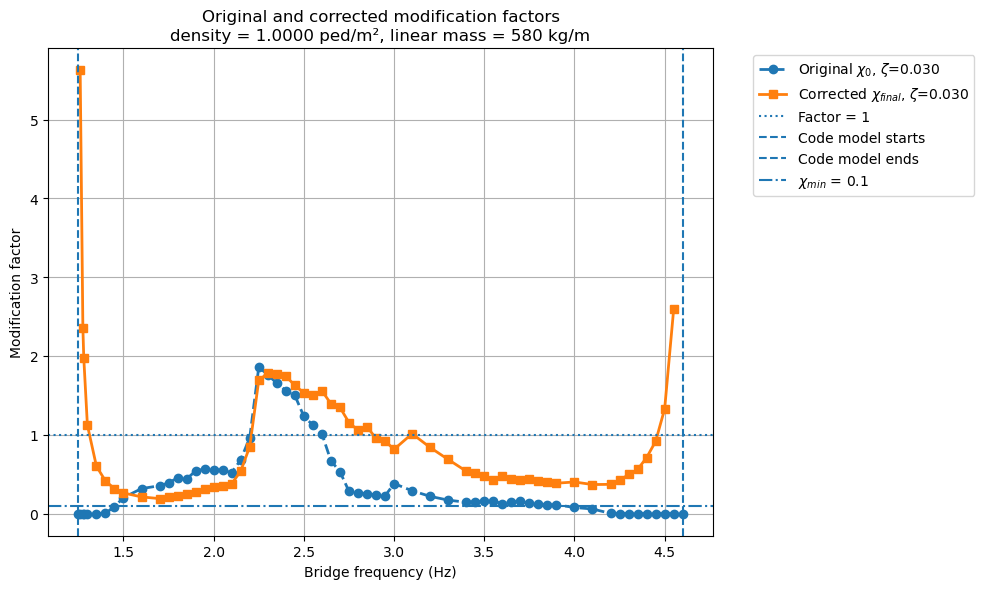

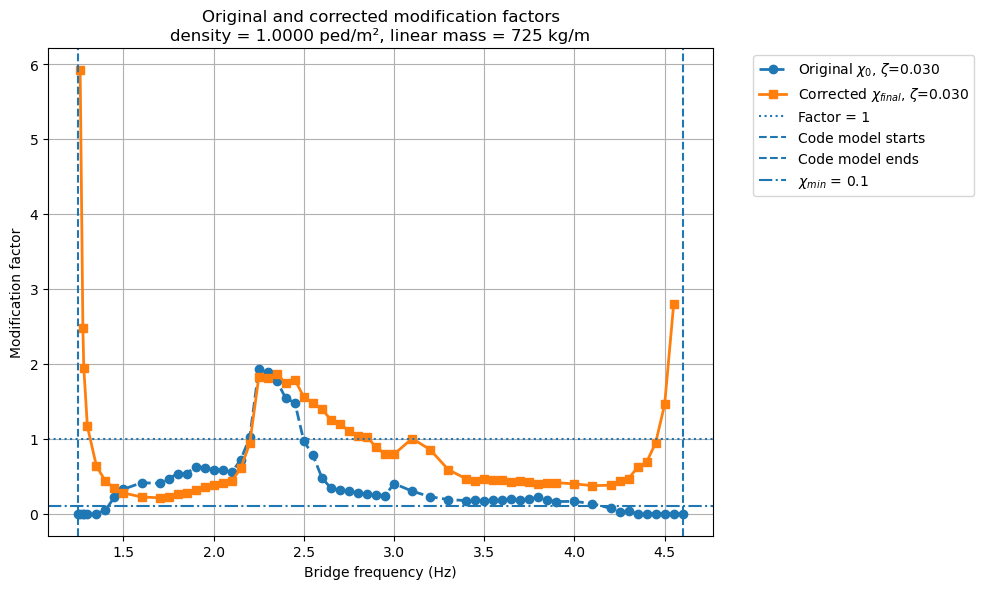

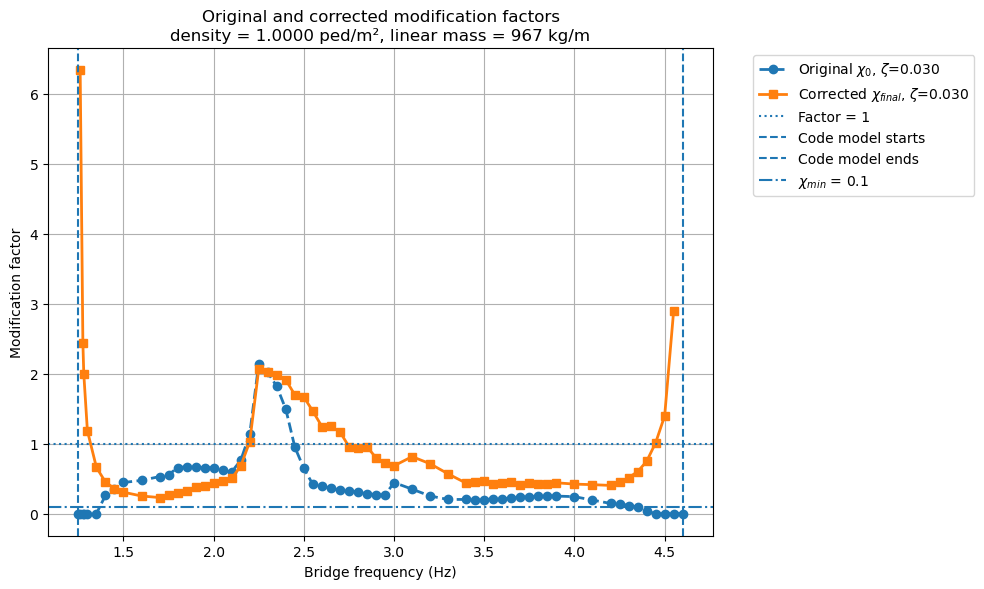

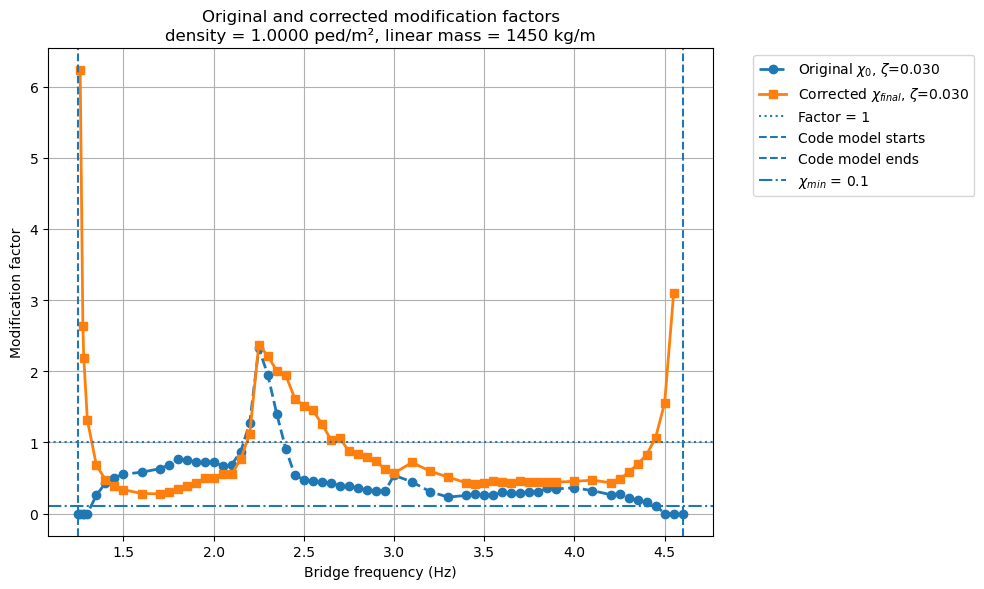

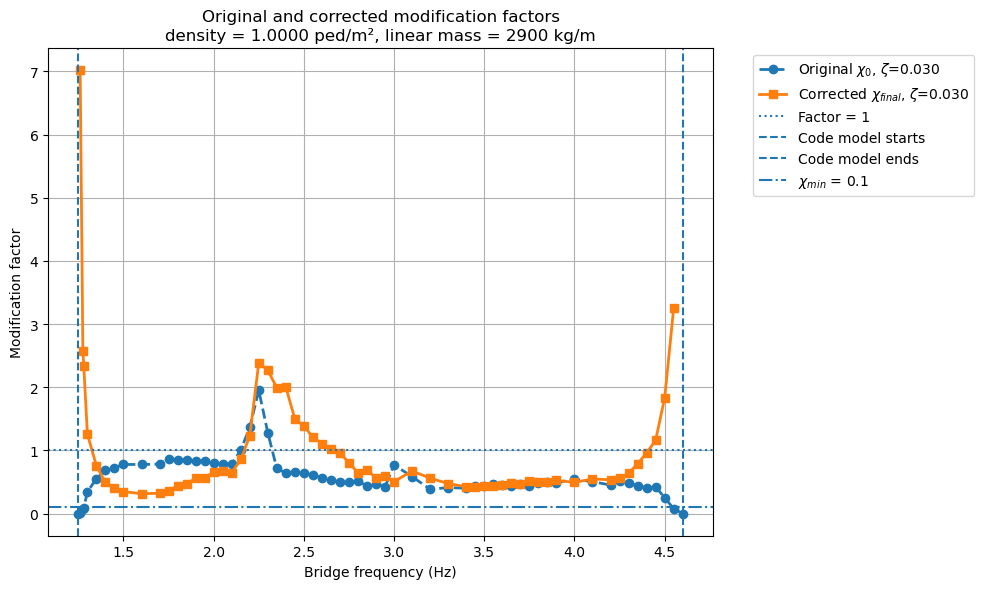


Correction method map
---------------------
     bridge_frequency  initial_modification_factor  final_modification_factor  \
0               1.200                          NaN                        NaN   
3               1.250                          0.0                        NaN   
6               1.260                          0.0                   5.628795   
9               1.275                          0.0                   2.357439   
12              1.280                          0.0                   1.972999   
..                ...                          ...                        ...   
174             4.400                          0.0                   0.710224   
177             4.450                          0.0                   0.916226   
180             4.500                          0.0                   1.328487   
183             4.550                          0.0                   2.592377   
186             4.600                          0.0              

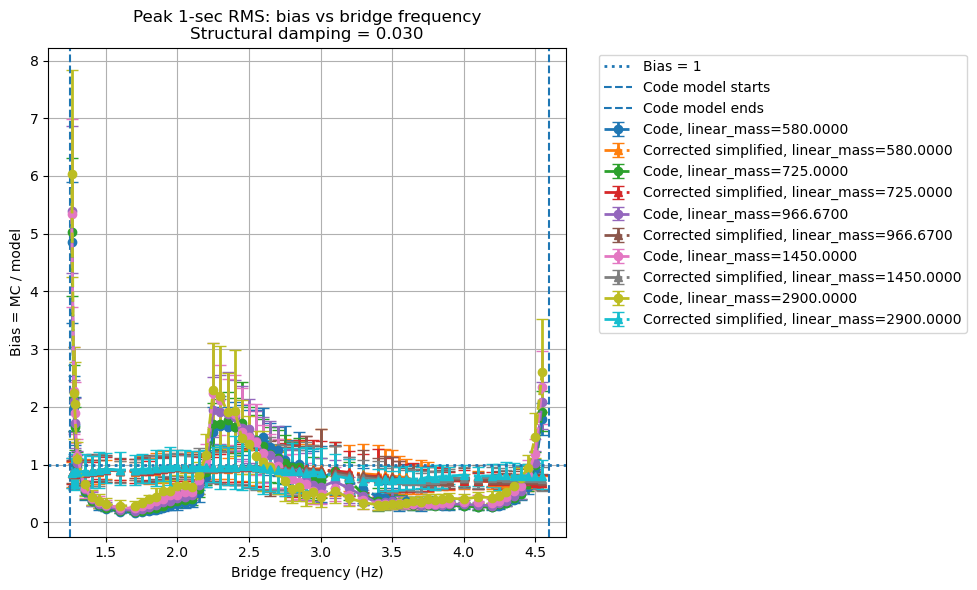

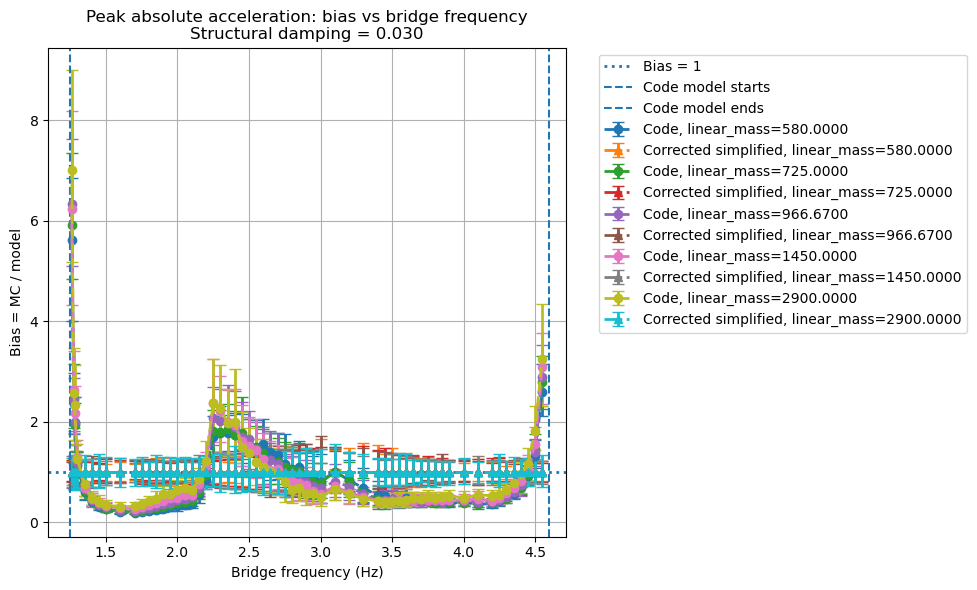

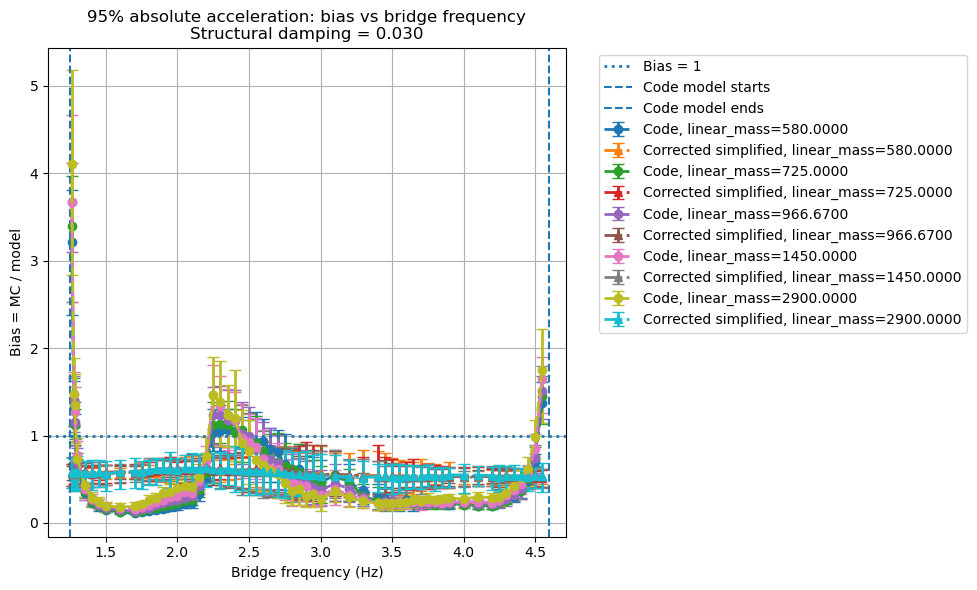

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import pickle
import pandas as pd

from bias_model2 import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_modification_factor_banded
)


# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 50
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0
target_beamdamp_values = [0.03]
# Give one damping ratio, or more if needed.
# Example: run all densities for structural damping = 0.020
linear_mass_values = [580.00, 725.00, 966.67, 1450.00, 2900.00]

bridge_frequencies_to_run = [
    1.20, 1.25, 1.26, 1.275, 1.28, 1.30, 1.35, 1.40, 1.45, 1.5,  1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7,
    2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.1, 3.2, 3.3, 3.40, 3.45, 3.5, 3.55, 3.60, 3.65, 3.70, 3.75, 3.80, 3.85, 3.90, 4.00, 4.10, 4.20, 4.25, 4.30, 4.35, 4.40, 4.45, 4.50, 4.55, 4.60


]

# Put all densities you want for the selected damping ratio here.
density = 1.0000

eps = 1e-12


# --------------------------------------------------
# Code-model validity and chi-threshold settings
# --------------------------------------------------
# The code UDL model is treated as valid only inside this frequency range.
# Outside this range, MC/reference results are stored and deterministic
# predictions are set to NaN.
CODE_MODEL_MIN_FREQ = 1.25
CODE_MODEL_MAX_FREQ = 4.60

# If the theoretical modification factor chi_0 is below this value,
# chi_0 is treated as unreliable and direct code-bias correction is used.
CHI_MIN_FOR_THEORY = 0.1


# --------------------------------------------------
# Bias-correction settings
# --------------------------------------------------
CALIBRATION_MEASURE = "Peak absolute acceleration"
CORRECTION_STAT = "mean"      # options: "mean", "median", "p95"


# --------------------------------------------------
# Modification-factor database
# --------------------------------------------------
FORCE_FACTOR_FILE = "NMFR_2.pkl"

MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: save name for each density-damping case
# --------------------------------------------------
def make_summary_filename(density, target_beamdamp, linear_mass):
    return (
        f"density{density:.4f}"
        f"_damping{target_beamdamp:.3f}"
        f"_lm{linear_mass:.0f}"
        f"_bias_summary.pkl"
    )
# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Helper: choose mean / median / p95 statistic
# --------------------------------------------------
def choose_stat(values, stat_name):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    if stat_name == "mean":
        return np.mean(values)

    elif stat_name == "median":
        return np.percentile(values, 50)

    elif stat_name == "p95":
        return np.percentile(values, 95)

    else:
        raise ValueError("CORRECTION_STAT must be 'mean', 'median', or 'p95'.")


# --------------------------------------------------
# Helper: safe bias distribution
# --------------------------------------------------
def safe_bias_distribution(Y_ref, model_value, eps=1e-12):
    Y_ref = np.asarray(Y_ref, dtype=float)
    Y_ref = Y_ref[np.isfinite(Y_ref)]

    if not np.isfinite(model_value):
        return np.full_like(Y_ref, np.nan, dtype=float)

    if abs(model_value) < eps:
        return np.full_like(Y_ref, np.nan, dtype=float)

    return Y_ref / model_value


# --------------------------------------------------
# Helper: safely summarize bias distribution
# --------------------------------------------------
def summarize_bias(B):
    B = np.asarray(B, dtype=float)
    B = B[np.isfinite(B)]

    if len(B) == 0:
        return np.nan, np.nan, np.nan, np.nan

    return (
        np.mean(B),
        np.percentile(B, 5),
        np.percentile(B, 50),
        np.percentile(B, 95),
    )


# --------------------------------------------------
# Helper: empty measures dictionary
# --------------------------------------------------
def empty_measures(measure_specs):
    return {
        spec["code_key"]: np.nan
        for spec in measure_specs.values()
    }


# --------------------------------------------------
# Response measures
# --------------------------------------------------
measure_specs = {
    "Peak 1-sec RMS": {
        "mc_key": "peak_rms",
        "code_key": "peak_1sec_rms",
    },
    "Peak absolute acceleration": {
        "mc_key": "peak_abs",
        "code_key": "peak_abs_acc",
    },
    "95% absolute acceleration": {
        "mc_key": "p95_abs",
        "code_key": "p95_abs_acc",
    },
}


# ==================================================
# MAIN LOOP
# ==================================================
if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    # --------------------------------------------------
    # Load modification-factor database
    # --------------------------------------------------
    with open(FORCE_FACTOR_FILE, "rb") as f:
        ff_data = pickle.load(f)

    ff_results_all = ff_data["results_all"]
    ff_densities = ff_data["densities"]
    ff_damping_values = ff_data["damping_values"]
    ff_pedBodyF = ff_data["pedBodyF"]

    ff_bands_to_combine = list(ff_results_all.keys())

    print("Loaded NEW modification-factor database.")
    print("Available bands:", ff_bands_to_combine)
    print("Available damping values:", ff_damping_values)
    print("Available densities:", ff_densities)

    # Optional safety check
    test_band = ff_bands_to_combine[0]
    test_damp = ff_damping_values[0]
    test_bf = sorted(ff_results_all[test_band][test_damp].keys())[0]
    test_density = ff_densities[0]
    test_keys = ff_results_all[test_band][test_damp][test_bf][test_density].keys()

    print("\nDatabase check")
    print("--------------")
    print("Test band:", test_band)
    print("Test damping:", test_damp)
    print("Test bridge frequency:", test_bf)
    print("Test density:", test_density)
    print("Available keys:", test_keys)

    if "modification_factor" not in test_keys:
        raise KeyError("The database does not contain 'modification_factor'.")

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    # This is only kept for plotting all densities together at the end.
    # Each density is saved separately immediately after that density is finished.
    all_summary_rows = []

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_beamdamp in target_beamdamp_values:

            print("\n" + "#" * 90)
            print(f"RUNNING STRUCTURAL DAMPING = {target_beamdamp:.4f}")
            print("#" * 90)

            # --------------------------------------------------
            # IMPORTANT CHANGE:
            # density loop is outside the frequency loop.
            # Therefore, once all frequencies for one density are finished,
            # that density gets saved immediately to its own PKL file.
            # --------------------------------------------------
            for linear_mass in linear_mass_values:

                density_summary_rows = []

                print("\n" + "*" * 90)
                print(f"STARTING LINEAR MASS = {linear_mass:.4f} FOR DAMPING = {target_beamdamp:.4f}")
                print("*" * 90)

                for target_bf in bridge_frequencies_to_run:

                    print("\n" + "=" * 80)
                    print(f"RUNNING BRIDGE FREQUENCY = {target_bf:.3f} Hz")
                    print("=" * 80)

                    BeamFreq = np.array([target_bf, 4.0 * target_bf])
                    Beamdamp = np.array([target_beamdamp])

                    print("\n" + "-" * 70)
                    print(f"Running linear mass = {linear_mass:.4f}")
                    print("-" * 70)

                    # --------------------------------------------------
                    # Convert density to integer pedestrian counts
                    # --------------------------------------------------
                    total_peds_float = density * Length * Width
                    total_peds_int = int(round(total_peds_float))
                    total_peds_int = max(1, total_peds_int)

                    Tocity = total_peds_int // 2
                    Outcity = total_peds_int - Tocity

                    actual_density = (Tocity + Outcity) / (Length * Width)

                    print(f"Target density   = {density:.4f}")
                    print(f"Actual density   = {actual_density:.4f}")
                    print(f"Total peds       = {total_peds_int}")
                    print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

                    # --------------------------------------------------
                    # Run MC reference simulations
                    # --------------------------------------------------
                    seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                    args_list = [
                        (
                            int(seeds[i]),
                            peddamp,
                            pedBodyF,
                            BeamFreq,
                            Beamdamp,
                            Tocity,
                            Outcity,
                            Length,
                            Width,
                            linear_mass
                        )
                        for i in range(NUM_SIMULATIONS)
                    ]
                    results = pool.map(run_simulation, args_list)

                    # --------------------------------------------------
                    # Extract MC acceleration histories and mass ratios
                    # --------------------------------------------------
                    accelerations = np.array([r[0] for r in results])
                    mean_mass_ratios = np.array([r[1] for r in results])

                    overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                    print(f"MC acceleration shape       = {accelerations.shape}")
                    print(f"Mean modal mass ratio       = {overall_mean_mass_ratio:.6f}")

                    # --------------------------------------------------
                    # Remove initial transient
                    # --------------------------------------------------
                    steady_start_idx = int(round(steady_start_time / hht))

                    if steady_start_idx >= accelerations.shape[1]:
                        raise ValueError(
                            "steady_start_time is longer than acceleration time history."
                        )

                    accelerations_ss = accelerations[:, steady_start_idx:]

                    # --------------------------------------------------
                    # MC response distributions
                    # --------------------------------------------------
                    rms_histories, peak_rms_values = peak_rms_distribution(
                        accelerations_ss,
                        dt=hht,
                        window_sec=1.0
                    )

                    peak_abs_values = peak_abs_acc_distribution(
                        accelerations_ss
                    )

                    p95_abs_values = percentile_acc_distribution(
                        accelerations_ss,
                        percentile=95,
                        use_abs=True
                    )

                    mc_values = {
                        "peak_rms": peak_rms_values,
                        "peak_abs": peak_abs_values,
                        "p95_abs": p95_abs_values,
                    }

                    # ==================================================
                    # CASE 1: OUTSIDE CODE MODEL RANGE
                    # ==================================================
                    code_model_exists = (
                        CODE_MODEL_MIN_FREQ <= target_bf <= CODE_MODEL_MAX_FREQ
                    )

                    if not code_model_exists:

                        print("\nCode UDL model is not defined for this frequency.")
                        print(
                            f"target_bf = {target_bf:.3f} Hz is outside "
                            f"[{CODE_MODEL_MIN_FREQ:.3f}, {CODE_MODEL_MAX_FREQ:.3f}] Hz"
                        )
                        print("Only MC/reference response will be stored.")

                        for measure_name, spec in measure_specs.items():

                            Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                            Y_ref = Y_ref[np.isfinite(Y_ref)]

                            row = {
                                "bridge_frequency": target_bf,
                                "target_beamdamp": target_beamdamp,
                                "target_density": density,
                                "actual_density": actual_density,
                                "linear_mass": linear_mass,
                                "total_peds": total_peds_int,
                                "Tocity": Tocity,
                                "Outcity": Outcity,

                                "mean_modal_mass_ratio": overall_mean_mass_ratio,
                                "mass_ratio_used_for_interpolation": np.nan,

                                "initial_modification_factor": np.nan,
                                "residual_correction_factor": np.nan,
                                "final_modification_factor": np.nan,

                                "calibration_measure": CALIBRATION_MEASURE,
                                "correction_stat": CORRECTION_STAT,
                                "correction_method": "outside_code_model_range",
                                "interpolation_status": "not_attempted",
                                "chi_min_for_theory": CHI_MIN_FOR_THEORY,

                                "measure": measure_name,

                                "mc_mean": np.mean(Y_ref),
                                "mc_p5": np.percentile(Y_ref, 5),
                                "mc_p50": np.percentile(Y_ref, 50),
                                "mc_p95": np.percentile(Y_ref, 95),

                                "code_prediction": np.nan,
                                "simplified_prediction": np.nan,
                                "corrected_prediction": np.nan,

                                "code_bias_mean": np.nan,
                                "code_bias_p5": np.nan,
                                "code_bias_p50": np.nan,
                                "code_bias_p95": np.nan,

                                "simplified_bias_mean": np.nan,
                                "simplified_bias_p5": np.nan,
                                "simplified_bias_p50": np.nan,
                                "simplified_bias_p95": np.nan,

                                "corrected_bias_mean": np.nan,
                                "corrected_bias_p5": np.nan,
                                "corrected_bias_p50": np.nan,
                                "corrected_bias_p95": np.nan,
                            }

                            density_summary_rows.append(row)
                            all_summary_rows.append(row)

                        continue

                    # ==================================================
                    # CASE 2: CODE MODEL EXISTS
                    # ==================================================

                    # --------------------------------------------------
                    # Original deterministic/code model
                    # --------------------------------------------------
                    t_end = accelerations.shape[1] * hht

                    code_result, code_measures = run_code_response_from_mc_inputs(
                        Tocity=Tocity,
                        Outcity=Outcity,
                        Length=Length,
                        Width=Width,
                        BeamFreq=BeamFreq,
                        Beamdamp=Beamdamp,
                        linear_mass=linear_mass,
                        hht=hht,
                        t_end=t_end,
                        mean_mass_ratio=overall_mean_mass_ratio,
                        mass_ratio_limit=0.05,
                        steady_start_time=steady_start_time,
                        numbers=1,
                        modify_both_modes=False,
                        force_reduction_factor=1.0
                    )

                    # --------------------------------------------------
                    # Interpolate original modification factor chi_0
                    # --------------------------------------------------
                    target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                        overall_mean_mass_ratio
                    )

                    x_factor = np.nan
                    interp_details = None
                    interpolation_status = "not_attempted"

                    try:
                        x_factor, interp_details = interpolate_modification_factor_banded(
                            results_all=ff_results_all,
                            target_bf=target_bf,
                            target_beamdamp=target_beamdamp,
                            target_mass_ratio=target_mass_ratio_used,
                            damping_values=ff_damping_values,
                            densities=ff_densities,
                            bands_to_combine=ff_bands_to_combine,
                            factor_key="modification_factor"
                        )

                        x_factor = float(x_factor)
                        interpolation_status = "success"

                    except Exception as e:
                        print("\nModification-factor interpolation failed.")
                        print(f"Reason: {e}")
                        x_factor = np.nan
                        interpolation_status = "failed"

                    print("\nModification-factor interpolation")
                    print("---------------------------------")
                    print(f"Target bf                        = {target_bf:.6f}")
                    print(f"Target damping                   = {target_beamdamp:.6f}")
                    print(f"MC mean modal mass ratio          = {overall_mean_mass_ratio:.6f}")
                    print(f"Mass ratio used in interpolation  = {target_mass_ratio_used:.6f}")
                    print(f"Interpolated factor chi_0         = {x_factor}")
                    print(f"Interpolation status              = {interpolation_status}")

                    # --------------------------------------------------
                    # Original simplified deterministic model using chi_0
                    # This is stored for comparison only.
                    # --------------------------------------------------
                    if np.isfinite(x_factor):

                        simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                            Tocity=Tocity,
                            Outcity=Outcity,
                            Length=Length,
                            Width=Width,
                            BeamFreq=BeamFreq,
                            Beamdamp=Beamdamp,
                            linear_mass=linear_mass,
                            hht=hht,
                            t_end=t_end,
                            mean_mass_ratio=overall_mean_mass_ratio,
                            mass_ratio_limit=0.05,
                            steady_start_time=steady_start_time,
                            numbers=1,
                            modify_both_modes=False,
                            force_reduction_factor=x_factor
                        )

                    else:
                        simplified_result = None
                        simplified_measures = empty_measures(measure_specs)

                    # --------------------------------------------------
                    # Decide correction method
                    # --------------------------------------------------
                    # Direct correction is triggered by the reliability of chi_0,
                    # not by a manually assigned frequency region.
                    #
                    # If chi_0 is missing or too small, the usual residual factor
                    # lambda = Y_MC / Y_simplified becomes unstable because
                    # Y_simplified = chi_0 * Y_code is near zero.
                    # In that case, directly calibrate the final factor from
                    # the code-model bias: chi_final = xi = stat(Y_MC / Y_code).
                    use_direct_code_bias_correction = False

                    if not np.isfinite(x_factor):
                        use_direct_code_bias_correction = True

                    elif abs(x_factor) < CHI_MIN_FOR_THEORY:
                        use_direct_code_bias_correction = True

                    # Calibration reference distribution
                    cal_spec = measure_specs[CALIBRATION_MEASURE]

                    Y_cal = np.asarray(mc_values[cal_spec["mc_key"]], dtype=float)
                    Y_cal = Y_cal[np.isfinite(Y_cal)]

                    code_val_cal = code_measures[cal_spec["code_key"]]

                    # --------------------------------------------------
                    # Direct code-bias correction
                    # --------------------------------------------------
                    if use_direct_code_bias_correction:

                        print("\nUsing DIRECT CODE-BIAS correction.")
                        print("Reason: missing chi_0 or chi_0 below the reliability threshold.")

                        correction_method = "direct_code_bias"

                        if (not np.isfinite(code_val_cal)) or (abs(code_val_cal) < eps):

                            print("WARNING: code prediction is zero or near zero.")
                            print("No multiplicative correction can recover the reference response.")

                            final_modification_factor = np.nan
                            residual_correction_factor = np.nan
                            correction_method = "failed_code_prediction_zero"

                        else:

                            B_code_cal = Y_cal / code_val_cal

                            final_modification_factor = choose_stat(
                                B_code_cal,
                                CORRECTION_STAT
                            )

                            residual_correction_factor = np.nan

                            print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                            print(f"Correction statistic       = {CORRECTION_STAT}")
                            print(f"Code calibration value     = {code_val_cal:.6e}")
                            print(f"Final factor from code bias = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Normal chi_0 * residual correction
                    # --------------------------------------------------
                    else:

                        print("\nUsing NORMAL theoretical + residual correction.")

                        correction_method = "theory_times_residual"

                        simp_val_cal = simplified_measures[cal_spec["code_key"]]

                        if (not np.isfinite(simp_val_cal)) or (abs(simp_val_cal) < eps):

                            print("WARNING: simplified prediction is zero or near zero.")
                            print("Switching to direct code-bias correction instead.")

                            if (not np.isfinite(code_val_cal)) or (abs(code_val_cal) < eps):

                                final_modification_factor = np.nan
                                residual_correction_factor = np.nan
                                correction_method = "failed_code_prediction_zero"

                            else:

                                B_code_cal = Y_cal / code_val_cal

                                final_modification_factor = choose_stat(
                                    B_code_cal,
                                    CORRECTION_STAT
                                )

                                residual_correction_factor = np.nan
                                correction_method = "direct_code_bias_fallback"

                        else:

                            B_simp_cal = Y_cal / simp_val_cal

                            residual_correction_factor = choose_stat(
                                B_simp_cal,
                                CORRECTION_STAT
                            )

                            final_modification_factor = x_factor * residual_correction_factor

                            print(f"Calibration measure        = {CALIBRATION_MEASURE}")
                            print(f"Correction statistic       = {CORRECTION_STAT}")
                            print(f"Initial factor chi_0        = {x_factor:.6f}")
                            print(f"Residual correction lambda  = {residual_correction_factor:.6f}")
                            print(f"Final factor chi_final      = {final_modification_factor:.6f}")

                    # --------------------------------------------------
                    # Corrected simplified deterministic model
                    # --------------------------------------------------
                    if np.isfinite(final_modification_factor):

                        corrected_result, corrected_measures = run_code_response_from_mc_inputs(
                            Tocity=Tocity,
                            Outcity=Outcity,
                            Length=Length,
                            Width=Width,
                            BeamFreq=BeamFreq,
                            Beamdamp=Beamdamp,
                            linear_mass=linear_mass,
                            hht=hht,
                            t_end=t_end,
                            mean_mass_ratio=overall_mean_mass_ratio,
                            mass_ratio_limit=0.05,
                            steady_start_time=steady_start_time,
                            numbers=1,
                            modify_both_modes=False,
                            force_reduction_factor=final_modification_factor
                        )

                    else:

                        corrected_result = None
                        corrected_measures = empty_measures(measure_specs)

                    print("\nCorrection summary")
                    print("------------------")
                    print(f"Correction method             = {correction_method}")
                    print(f"Initial factor chi_0           = {x_factor}")
                    print(f"Residual correction factor     = {residual_correction_factor}")
                    print(f"Final modification factor      = {final_modification_factor}")

                    # --------------------------------------------------
                    # Bias distributions for all 3 measures
                    # --------------------------------------------------
                    for measure_name, spec in measure_specs.items():

                        Y_ref = np.asarray(mc_values[spec["mc_key"]], dtype=float)
                        Y_ref = Y_ref[np.isfinite(Y_ref)]

                        code_val = code_measures[spec["code_key"]]
                        simp_val = simplified_measures[spec["code_key"]]
                        corr_val = corrected_measures[spec["code_key"]]

                        B_code = safe_bias_distribution(Y_ref, code_val, eps=eps)
                        B_simp = safe_bias_distribution(Y_ref, simp_val, eps=eps)
                        B_corr = safe_bias_distribution(Y_ref, corr_val, eps=eps)

                        (
                            code_bias_mean,
                            code_bias_p5,
                            code_bias_p50,
                            code_bias_p95,
                        ) = summarize_bias(B_code)

                        (
                            simplified_bias_mean,
                            simplified_bias_p5,
                            simplified_bias_p50,
                            simplified_bias_p95,
                        ) = summarize_bias(B_simp)

                        (
                            corrected_bias_mean,
                            corrected_bias_p5,
                            corrected_bias_p50,
                            corrected_bias_p95,
                        ) = summarize_bias(B_corr)

                        row = {
                            "bridge_frequency": target_bf,
                            "target_beamdamp": target_beamdamp,
                            "target_density": density,
                            "actual_density": actual_density,
                            "linear_mass": linear_mass,
                            "total_peds": total_peds_int,
                            "Tocity": Tocity,
                            "Outcity": Outcity,

                            "mean_modal_mass_ratio": overall_mean_mass_ratio,
                            "mass_ratio_used_for_interpolation": target_mass_ratio_used,

                            "initial_modification_factor": x_factor,
                            "residual_correction_factor": residual_correction_factor,
                            "final_modification_factor": final_modification_factor,

                            "calibration_measure": CALIBRATION_MEASURE,
                            "correction_stat": CORRECTION_STAT,
                            "correction_method": correction_method,
                            "interpolation_status": interpolation_status,
                            "chi_min_for_theory": CHI_MIN_FOR_THEORY,

                            "measure": measure_name,

                            "mc_mean": np.mean(Y_ref),
                            "mc_p5": np.percentile(Y_ref, 5),
                            "mc_p50": np.percentile(Y_ref, 50),
                            "mc_p95": np.percentile(Y_ref, 95),

                            "code_prediction": code_val,
                            "simplified_prediction": simp_val,
                            "corrected_prediction": corr_val,

                            "code_bias_mean": code_bias_mean,
                            "code_bias_p5": code_bias_p5,
                            "code_bias_p50": code_bias_p50,
                            "code_bias_p95": code_bias_p95,

                            "simplified_bias_mean": simplified_bias_mean,
                            "simplified_bias_p5": simplified_bias_p5,
                            "simplified_bias_p50": simplified_bias_p50,
                            "simplified_bias_p95": simplified_bias_p95,

                            "corrected_bias_mean": corrected_bias_mean,
                            "corrected_bias_p5": corrected_bias_p5,
                            "corrected_bias_p50": corrected_bias_p50,
                            "corrected_bias_p95": corrected_bias_p95,
                        }

                        density_summary_rows.append(row)
                        all_summary_rows.append(row)

                        print(f"\n{measure_name}")
                        print(f"  MC mean                   = {np.mean(Y_ref):.6f}")
                        print(f"  Code prediction           = {code_val}")
                        print(f"  Simplified prediction     = {simp_val}")
                        print(f"  Corrected prediction      = {corr_val}")
                        print(f"  Code mean bias            = {code_bias_mean}")
                        print(f"  Simplified mean bias      = {simplified_bias_mean}")
                        print(f"  Corrected simplified bias = {corrected_bias_mean}")

                # ==================================================
                # SAVE THIS DENSITY IMMEDIATELY
                # ==================================================
                density_summary_df = pd.DataFrame(density_summary_rows)
                summary_pkl = make_summary_filename(density, target_beamdamp, linear_mass)
                with open(summary_pkl, "wb") as f:
                    pickle.dump(density_summary_df, f, protocol=pickle.HIGHEST_PROTOCOL)

                print("\n" + "=" * 80)
                print("Saved density summary file:")
                print(summary_pkl)
                print("Rows saved:", len(density_summary_df))
                print("=" * 80)

    # ==================================================
    # PLOTS USING ALL RESULTS FROM THIS RUN
    # No combined PKL is saved here; only individual density PKLs are saved above.
    # ==================================================
    summary_df = pd.DataFrame(all_summary_rows)

    if len(summary_df) == 0:
        print("No results to plot.")
    else:
        # ==================================================
        # PLOT 1: ORIGINAL vs CORRECTED MODIFICATION FACTOR
        # One plot per density, all damping ratios included
        # ==================================================
        factor_df = summary_df.drop_duplicates(
            subset=[
                "bridge_frequency",
                "target_density",
                "target_beamdamp",
                "linear_mass"
            ]
        ).copy()

        for linear_mass in linear_mass_values:

            plt.figure(figsize=(10, 6))

            for target_beamdamp in target_beamdamp_values:

                sub = factor_df[
                    (np.isclose(factor_df["target_density"], density)) &
                    (np.isclose(factor_df["target_beamdamp"], target_beamdamp)) &
                    (np.isclose(factor_df["linear_mass"], linear_mass))
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                plt.plot(
                    sub["bridge_frequency"],
                    sub["initial_modification_factor"],
                    marker="o",
                    linestyle="--",
                    linewidth=2,
                    label=rf"Original $\chi_0$, $\zeta$={target_beamdamp:.3f}"
                )

                plt.plot(
                    sub["bridge_frequency"],
                    sub["final_modification_factor"],
                    marker="s",
                    linestyle="-",
                    linewidth=2,
                    label=rf"Corrected $\chi_{{final}}$, $\zeta$={target_beamdamp:.3f}"
                )

            plt.axhline(
                1.0,
                linestyle=":",
                linewidth=1.5,
                label="Factor = 1"
            )

            plt.axvline(
                CODE_MODEL_MIN_FREQ,
                linestyle="--",
                linewidth=1.5,
                label="Code model starts"
            )

            plt.axvline(
                CODE_MODEL_MAX_FREQ,
                linestyle="--",
                linewidth=1.5,
                label="Code model ends"
            )

            plt.axhline(
                CHI_MIN_FOR_THEORY,
                linestyle="-.",
                linewidth=1.5,
                label=rf"$\chi_{{min}}$ = {CHI_MIN_FOR_THEORY}"
            )

            plt.xlabel("Bridge frequency (Hz)")
            plt.ylabel("Modification factor")
            plt.title(
                f"Original and corrected modification factors\n"
                f"density = {density:.4f} ped/m², "
                f"linear mass = {linear_mass:.0f} kg/m"
            )

            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
            plt.tight_layout()
            plt.show()

        # ==================================================
        # PLOT 2: CORRECTION METHOD MAP
        # ==================================================
        for linear_mass in linear_mass_values:
            
            for target_beamdamp in target_beamdamp_values:

                sub = factor_df[
                    (np.isclose(factor_df["target_density"], density)) &
                    (np.isclose(factor_df["target_beamdamp"], target_beamdamp)) &
                    (np.isclose(factor_df["linear_mass"], linear_mass))
                ].copy()

                sub = sub.sort_values("bridge_frequency")

                print("\nCorrection method map")
                print("---------------------")
                print(
                    sub[
                        [
                            "bridge_frequency",
                            "initial_modification_factor",
                            "final_modification_factor",
                            "correction_method",
                            "interpolation_status",
                            "linear_mass"
                        ]
                    ]
                )

        # ==================================================
        # PLOTS 3-5: ERROR BARS FOR EACH RESPONSE MEASURE
        # One plot per vibration measure and damping ratio
        # Code and corrected simplified are plotted.
        # Points outside [1.25, 4.60] Hz appear as NaN for deterministic models.
        # ==================================================
        for target_beamdamp in target_beamdamp_values:

            for measure_name in measure_specs.keys():

                plt.figure(figsize=(10, 6))

                for linear_mass in linear_mass_values:

                    sub = summary_df[
                        (np.isclose(summary_df["target_beamdamp"], target_beamdamp)) &
                        (np.isclose(summary_df["linear_mass"], linear_mass)) &
                        (summary_df["measure"].astype(str) == str(measure_name))
                    ].copy()

                    sub = sub.sort_values("bridge_frequency")

                    x = sub["bridge_frequency"].values

                    # -----------------------------
                    # Original code bias
                    # -----------------------------
                    y_code = sub["code_bias_mean"].values
                    y_code_p5 = sub["code_bias_p5"].values
                    y_code_p95 = sub["code_bias_p95"].values

                    yerr_code = np.vstack([
                        y_code - y_code_p5,
                        y_code_p95 - y_code
                    ])

                    plt.errorbar(
                        x,
                        y_code,
                        yerr=yerr_code,
                        marker="o",
                        linestyle="--",
                        linewidth=2,
                        capsize=4,
                        label=f"Code, linear_mass={linear_mass:.4f}"
                    )

                    # -----------------------------
                    # Corrected simplified model bias
                    # -----------------------------
                    y_corr = sub["corrected_bias_mean"].values
                    y_corr_p5 = sub["corrected_bias_p5"].values
                    y_corr_p95 = sub["corrected_bias_p95"].values

                    yerr_corr = np.vstack([
                        y_corr - y_corr_p5,
                        y_corr_p95 - y_corr
                    ])

                    plt.errorbar(
                        x,
                        y_corr,
                        yerr=yerr_corr,
                        marker="^",
                        linestyle="-.",
                        linewidth=2,
                        capsize=4,
                        label=f"Corrected simplified, linear_mass={linear_mass:.4f}"
                    )

                plt.axhline(
                    1.0,
                    linestyle=":",
                    linewidth=2,
                    label="Bias = 1"
                )

                plt.axvline(
                    CODE_MODEL_MIN_FREQ,
                    linestyle="--",
                    linewidth=1.5,
                    label="Code model starts"
                )

                plt.axvline(
                    CODE_MODEL_MAX_FREQ,
                    linestyle="--",
                    linewidth=1.5,
                    label="Code model ends"
                )

                plt.xlabel("Bridge frequency (Hz)")
                plt.ylabel("Bias = MC / model")
                plt.title(
                    f"{measure_name}: bias vs bridge frequency\n"
                    f"Structural damping = {target_beamdamp:.3f}"
                )

                plt.grid(True)
                plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
                plt.tight_layout()
                plt.show()
